# Black target control

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


/app/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env_aws.py
%run run.py connect

/app/.venv/lib/python3.9/site-packages/datajoint/plugin.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-02-25 13:24:25,571][INFO]: Connecting admin@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306
[2026-02-25 13:24:25,734][INFO]: Connected admin@vr4mice-ar-collab.cluster-cn54f38qpzgm.eu-central-1.rds.amazonaws.com:3306


In [78]:
from vr4mice.schema.base_analysis import DataFrame
from vr4mice.schema.vr4mice import Dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting, regression
from vr4mice.schema.interpolated_trajectories import InterpolatedTrials, MeanXYTrajectory, MeanVelocities,YBinnedXYTrajectory
from vr4mice.schema.session_metrics import TrialMetrics
from vr4mice.schema.decision import PredictionModel, DecisionPoints, InclusionStatus, ExperimentMember, LabelSet, Label
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.analysis import utils, plotting
from vr4mice.analysis.stats import get_multi_p_values_binned, get_multi_p_values_global, plot_aperture_heatmap

from statsmodels.stats.anova import AnovaRM

from scipy.stats import ttest_rel, ttest_ind
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")

import matplotlib.colors as mcolors
import matplotlib.cm as cm


style()

save_fig_path = "notebooks/Paper_figures/Figure_output/"

In [5]:
from vr4mice.schema.vr4mice import FailedSession

## Dual-occlusion analysis

In [6]:
trial_df = (TrialMetrics() * (vr4mice.Dataset() & 'session_label = "ar_discrim_occluders_inv"')).fetch(as_dict=True)
trial_df =  pd.concat([pd.DataFrame(x) for x in trial_df])

# Exclude sessions that were not in the list
trial_df, reward_table = utils.apply_inclusion_criteria(trial_df,
                                                        return_excluded=False)
trial_df = trial_df[trial_df.dataset != "Hamster_2026-02-02_1"] # Exclude session with no dlc video

# Create list of included datasets
mouse_list = trial_df.dataset.unique()
trial_df["mouse_name"] = trial_df.dataset.str.split("_").str[0]

In [7]:
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})

In [8]:
trial_df.mouse_name.nunique(), trial_df.dataset.nunique()

(3, 15)

In [9]:
trial_df.mouse_name.unique()

array(['Flamingo', 'Grizzly', 'Hamster'], dtype=object)

In [10]:
trial_df.groupby("mouse_name").nunique().dataset

mouse_name
Flamingo    6
Grizzly     5
Hamster     4
Name: dataset, dtype: int64

### Rate plots

In [11]:
trial_df["lab_id"] = 0
for dataset_name in mouse_list:
    # Fetch lab_id for each dataset
    trial_df.loc[trial_df.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

4.3: mean=0.741 ± 0.022
12.0-4.3: TtestResult(statistic=4.3469830719398646, pvalue=0.0006698811968695812, df=14)
12.0: mean=0.900 ± 0.019


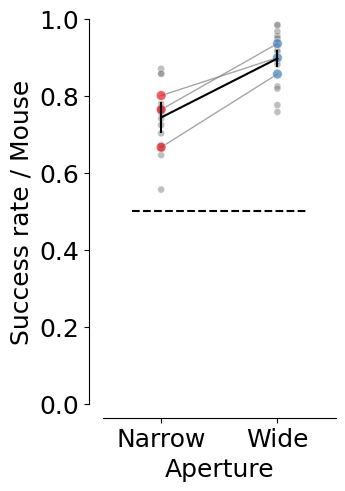

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True,
)

ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)
plt.ylim(0, 1.0)
plt.xlim(-0.5, 1.5)
ax.set_ylabel("Success rate / Mouse")
ax.set_xlabel("Aperture")
ax.set_xticks([0, 1], ["Narrow", "Wide"])
sns.despine(offset=10)
plt.legend([], [], frameon=False)
plt.savefig(save_fig_path + "supp_contrast_trial_reward.svg", transparent=True)

wide aperture mean:  0.508655783006373 std:  0.02774361461722577
narrow aperture mean:  0.49134421699362696 std:  0.027743614617225784


TtestResult(statistic=1.167366793078196, pvalue=0.262560598358068, df=14)

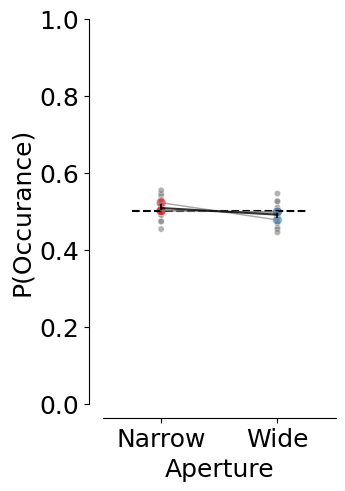

In [13]:
# Occurance of the different conditions
counts = (
    trial_df.groupby(["dataset", "mouse_name", "aperture"])
    .trial.nunique()
    .reset_index(name="trial_count")
)
total_trials = (
    trial_df.groupby("dataset").trial.nunique().reset_index(name="total_trials")
)

counts = counts.merge(total_trials, on="dataset")
counts["probability"] = counts["trial_count"] / counts["total_trials"]
counts.sort_values("aperture", inplace=True)
counts["aperture"] = counts.aperture.astype("str")

fig, ax = plt.subplots(1, 1, figsize=(3, 5))

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    units="mouse_name",
    estimator=None,
    ax=ax,
    color="grey",
    alpha=0.7,
    linewidth=1,
    zorder=3,
)

sns.scatterplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    hue="aperture",
    ax=ax,
    palette=plotting.colors_aperture,
    alpha=0.6,
    s=50,
    zorder=2,
)

sns.scatterplot(
    data=counts,
    x="aperture",
    y="probability",
    hue="aperture",
    ax=ax,
    palette=["grey"] * counts["dataset"].nunique(),
    alpha=0.6,
    zorder=1,
    s=20,
)

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    ax=ax,
    color="black",
    err_style="bars",
    errorbar="se",
    alpha=0.8,
    zorder=4,
)

ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

plt.ylim(0, 1)
plt.xlim(-0.5, 1.5)
plt.xticks([0, 1], ["Narrow", "Wide"])

plt.xlabel("Aperture")
plt.ylabel("P(Occurance)")
sns.despine(offset=10)
plt.legend([], [], frameon=False)

plt.savefig(save_fig_path + "supp_contrast_trial_number.svg", transparent=True)

counts = counts.pivot(index="dataset", columns=["aperture"], values=["probability"])
print(
    "wide aperture mean: ",
    np.mean(np.array(counts["probability"]["12.0"])),
    "std: ",
    np.std(np.array(counts["probability"]["12.0"])),
)
print(
    "narrow aperture mean: ",
    np.mean(np.array(counts["probability"]["4.3"])),
    "std: ",
    np.std(np.array(counts["probability"]["4.3"])),
)
ttest_rel(
    np.array(counts["probability"]["12.0"]), np.array(counts["probability"]["4.3"])
)

4.3: mean=0.135 ± 0.085
12.0-4.3: TtestResult(statistic=-0.17219823726971856, pvalue=0.8657461439506684, df=14)
12.0: mean=0.116 ± 0.041
12.0 vs chance 0: t=1.74, p=0.223
4.3 vs chance 0: t=0.76, p=0.526


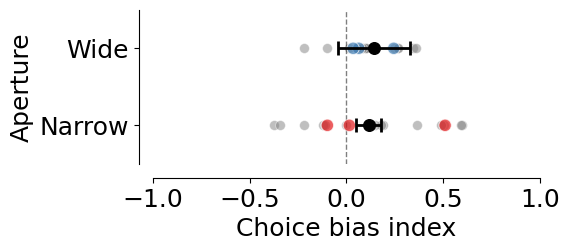

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(5, 2))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_left_choice",
    per_aperture=True,
    plot_bias=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True,
)

ax.set_ylim(-0.5, 1.5)
ax.set_ylabel("Aperture")
ax.set_yticks([1, 0], ["Wide", "Narrow"])
ax.set_xlim(-1, 1)
plt.legend([], [], frameon=False)
plt.xlabel("Choice bias index")

ax.axvline(x=0, color="black", linestyle="--", linewidth=1, alpha=0.5)
sns.despine(offset=10)

plt.savefig(save_fig_path + "supp_contrast_choice_bias.svg", transparent=True)

In [15]:
# Stickiness of the decision
trial_df["trial_history"] = trial_df.groupby(
                    ["dataset"]
                )["trial_left_choice"].transform(lambda x: x.shift(1)).fillna(0)

trial_df["decision_stickiness"] = (
    (trial_df['trial_left_choice'] == trial_df['trial_history'])
    .groupby([trial_df['dataset'], trial_df['trial']])
    .transform('mean')
)

4.3: mean=0.009 ± 0.033
12.0-4.3: TtestResult(statistic=0.03758014588624681, pvalue=0.9705530506869855, df=14)
12.0: mean=0.010 ± 0.022
12.0 vs chance 0: t=0.32, p=0.782
4.3 vs chance 0: t=0.15, p=0.893


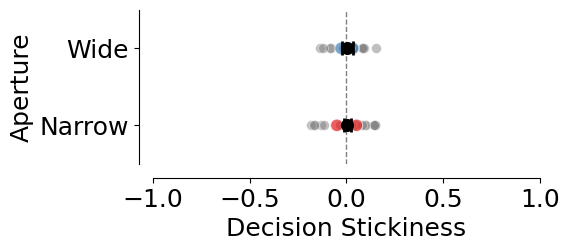

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(5, 2))
plotting.plot_rate(
    df=trial_df,
    label_x="decision_stickiness",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True,
    plot_bias=True,
)

ax.set_ylim(-0.5, 1.5)
ax.set_yticks([0, 1], ["Narrow", "Wide"])
ax.set_ylabel("Aperture")
ax.set_xlim(-1, 1)
plt.legend([], [], frameon=False)
plt.xlabel("Decision Stickiness")

ax.axvline(x=0, color="black", linestyle="--", linewidth=1, alpha=0.5)

sns.despine(offset=10)

plt.savefig(save_fig_path + "supp_contrast_decision_stickiness.svg", transparent=True)

Overall mean:  0.95128327247454 0.008728677583401985


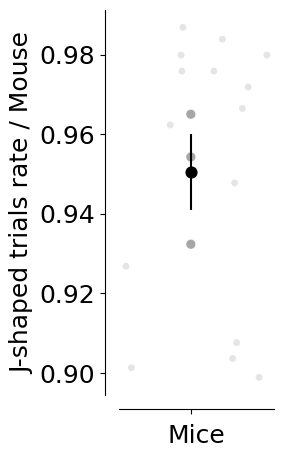

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(2, 5))

counts = (
    trial_df
    .groupby(["mouse_name", "dataset"], as_index=False)
    .trial_jshaped.mean()
)

counts["count"] = counts["trial_jshaped"]
counts = pd.DataFrame(counts.reset_index())

plotting._plot_bar_counts(
    counts=counts,
    label_x=None,
    alpha=0.2,
    ax=ax,
    per_mouse=True,
    cmap=["grey"],
)

ax.set_ylabel("J-shaped trials rate / Mouse")
ax.set_xlabel("Mice")
plt.legend([], [], frameon=False)
sns.despine(offset=10)

print(f"Overall mean: ", np.mean(counts['trial_jshaped']), stats.sem(counts['trial_jshaped']))
plt.savefig(save_fig_path + "supp_contrast_trial_jshaped.svg", transparent=True)

### Trajectory analysis

In [18]:
xy_df = []
for m in mouse_list:
    print(m)
    xy_df.append(pd.DataFrame((MeanXYTrajectory() & f'dataset="{m}"').fetch(as_dict=True)[0]))
xy_df = pd.concat(xy_df)
xy_df["mouse_name"] = xy_df.dataset.str.split("_").str [0]

Flamingo_2026-02-02_1
Flamingo_2026-02-03_1
Flamingo_2026-02-04_1
Flamingo_2026-02-05_1
Flamingo_2026-02-06_1
Flamingo_2026-02-09_1
Grizzly_2026-02-03_1
Grizzly_2026-02-04_1
Grizzly_2026-02-05_1
Grizzly_2026-02-09_1
Grizzly_2026-02-11_1
Hamster_2026-02-03_1
Hamster_2026-02-04_1
Hamster_2026-02-06_1
Hamster_2026-02-09_1


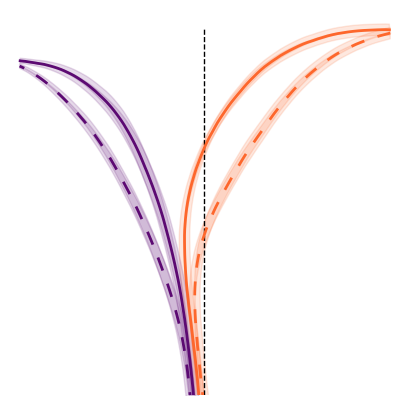

In [19]:
# Mean and error by session
mean_session = analysis.mean_xy_trajectory(xy_df,
                                         index_columns=[
                                             "dataset", "mouse_name", "aperture", "trial_left_choice", "trial_length"
                                         ])

# Mean and error by aperture and choice
mean_group = analysis.mean_xy_trajectory(mean_session, 
                                         index_columns=[
                                             "aperture",  "trial_left_choice", "trial_length"
                                         ])

# Plot the mean trajectories
plotting.plot_mean_xy_trajectory(mean_group, cmap=plotting.colors_choice[::-1], color_by="choice", style_by="aperture")
plt.savefig(save_fig_path + "figure_2_mean_xy_trajectories.svg", transparent=True)
plt.savefig(save_fig_path + "figure_2_mean_xy_trajectories.png", transparent=True, dpi=300)

In [20]:
# Mean and error by mouse
mean_mouse = analysis.mean_xy_trajectory(xy_df, 
                                         index_columns= [
                                             "mouse_name", "aperture", "trial_left_choice", "trial_length"
                                         ])

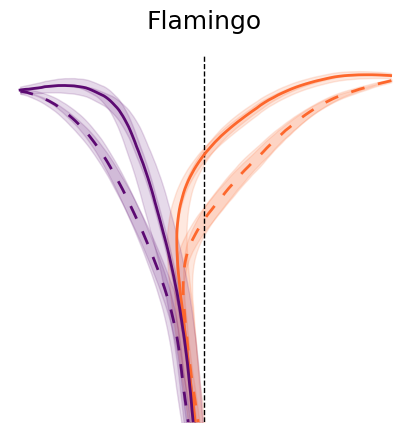

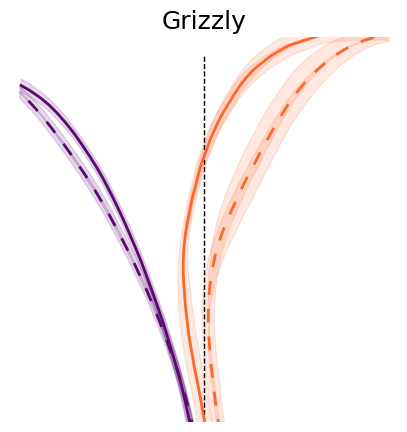

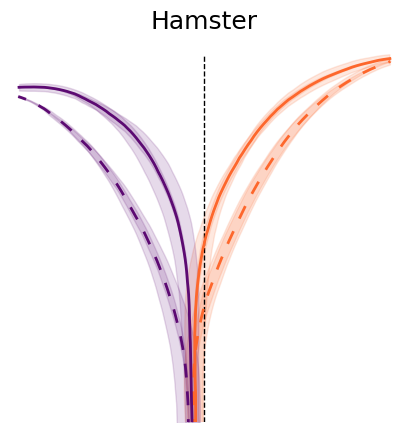

In [21]:
for m in mean_mouse.mouse_name.unique():
    plotting.plot_mean_xy_trajectory(mean_mouse[mean_mouse.mouse_name == m], 
                                     cmap=plotting.colors_choice[::-1], color_by="choice", style_by="aperture")
    plt.title(m)
    plt.savefig(save_fig_path + f"supp_contrast_dual_occluders_trajectories_time_{m}.svg", transparent=True)
    plt.savefig(save_fig_path + f"supp_contrast_dual_occluders_trajectories_time_{m}.png", transparent=True, dpi=300)

In [22]:
y_binned_df = []
for m in mouse_list:
    try:
        y_binned_df.append(pd.DataFrame((InterpolatedTrials() & f'dataset="{m}"').fetch("dataset", "aperture", "trial", "x", "y", "flip_one_side", "trial_left_choice", as_dict=True)[0]))
    except Exception as err:
        print(err)
y_binned_df = pd.concat(y_binned_df)

In [23]:
y_binned_df["mouse_name"] = y_binned_df.dataset.str.split("_").str [0]
y_binned_df["x_flipped"] = y_binned_df.x * y_binned_df.flip_one_side
data = utils.create_bins(y_binned_df, 
                         spatial_ybins=[-13, 24, 30])
y_binned_df_mean = analysis.mean_xy_trajectory(data, 
                                               index_columns=["dataset", "mouse_name", "aperture", "bin_centers"], 
                                               values=["x_flipped", "y"])

                        Anova
                     F Value   Num DF  Den DF  Pr > F
-----------------------------------------------------
aperture              11.9600  1.0000  14.0000 0.0038
bin_centers          221.9727 14.0000 196.0000 0.0000
aperture:bin_centers   5.7969 14.0000 196.0000 0.0000



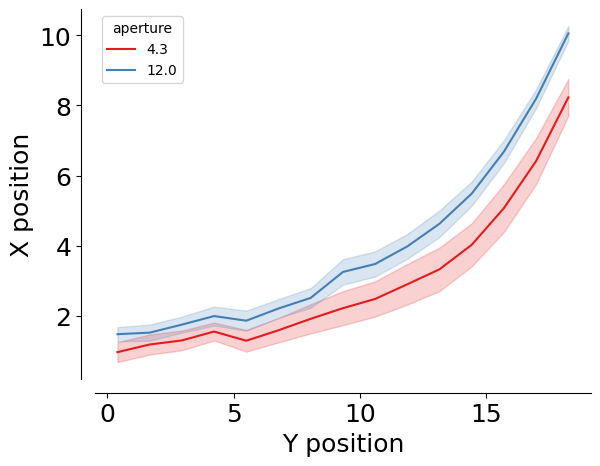

In [24]:
stats_binned = y_binned_df_mean[(y_binned_df_mean.bin_centers >= 0) & (y_binned_df_mean.bin_centers < 19)]

sns.lineplot(data=stats_binned, x="bin_centers", y="x_flipped", hue="aperture", 
             palette= plotting.colors_aperture, errorbar="se")
plt.xlabel("Y position")
plt.ylabel("X position")

sns.despine(offset=10)
plt.savefig(save_fig_path + "supp_contrast_mean_xy_trajectory.svg", transparent=True)

print(
    AnovaRM(
        data=stats_binned,
        depvar="x_flipped",
        subject="dataset",
        within=["aperture", "bin_centers"],
    ).fit()
)

In [25]:
p_values = []
for i in stats_binned.bin_centers.unique():
    section = stats_binned [stats_binned.bin_centers == i]
    t = ttest_rel(
        section[section.aperture == section.aperture.unique()[0]].x_flipped,
        section[section.aperture == section.aperture.unique()[1]].x_flipped,
    )
    p_values.append(pd.DataFrame({"segment": i, "p_value": t.pvalue}, index=[0]))

p_value_df = pd.concat(p_values)
p_value_df["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

In [26]:
# Closest value to 0.05 in the corrected p-values
cross_sign = p_value_df[p_value_df.p_value_corr <= 0.05].iloc[0]

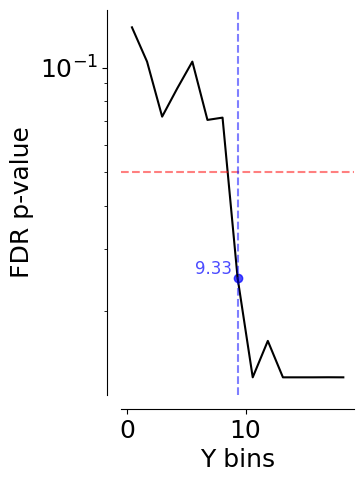

In [27]:
fig = plt.figure(figsize=(3, 5))
sns.lineplot(data=p_value_df, x="segment", y="p_value_corr", c="black")
plt.axhline(0.05, linestyle="dashed", color="red", alpha=0.5)
plt.xlabel("Y bins")
plt.ylabel("FDR p-value")
plt.yscale("log")
plt.axvline(x=cross_sign.segment, linestyle="dashed", color="blue", alpha=0.5)
# add the value of the y position at the crossing point
plt.text(cross_sign.segment - 0.5, cross_sign.p_value_corr, f"{cross_sign.segment:.2f}", 
         color="blue", fontsize=12, verticalalignment="bottom", horizontalalignment="right", alpha=0.7)
plt.scatter(data=cross_sign, x="segment", y="p_value_corr", color="blue", alpha=0.7)
sns.despine(offset=10)
plt.savefig(save_fig_path + "supp_contrast_position_p_values.svg", transparent=True)

### Velocity analysis

In [28]:
velocity_df = []
for m in mouse_list:
    print(m)
    velocity_df.append(pd.DataFrame((MeanVelocities() & f'dataset="{m}"').fetch(as_dict=True)[0]))
velocity_df = pd.concat(velocity_df)

Flamingo_2026-02-02_1
Flamingo_2026-02-03_1
Flamingo_2026-02-04_1
Flamingo_2026-02-05_1
Flamingo_2026-02-06_1
Flamingo_2026-02-09_1
Grizzly_2026-02-03_1
Grizzly_2026-02-04_1
Grizzly_2026-02-05_1
Grizzly_2026-02-09_1
Grizzly_2026-02-11_1
Hamster_2026-02-03_1
Hamster_2026-02-04_1
Hamster_2026-02-06_1
Hamster_2026-02-09_1


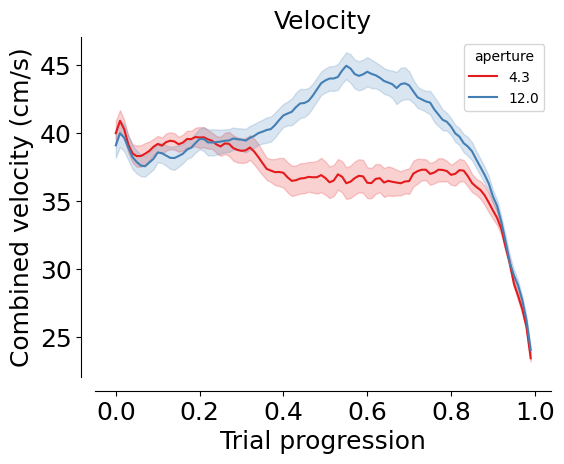

In [29]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax = ax

sns.lineplot(
    data=velocity_df,
    x="trial_length",
    y="velocity",
    palette=(
        plotting.colors_aperture[:2]
        if len(mean_mouse.aperture.unique()) == 2
        else plotting.colors_aperture[:2]
    ),
    hue="aperture",
    errorbar="se",
    ax=ax,
)
ax.set_title(f"Velocity")
sns.despine(offset=10)
ax.set_xlabel("Trial progression")
ax.set_ylabel("Combined velocity (cm/s)")
plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "supp_contrast_mean_velocity.svg", transparent=True)

In [30]:
print(
    AnovaRM(
        data=velocity_df,
        depvar="velocity",
        subject="dataset",
        within=["aperture", "trial_length"],
    ).fit()
)

                        Anova
                      F Value  Num DF   Den DF  Pr > F
------------------------------------------------------
aperture              63.0720  1.0000   14.0000 0.0000
trial_length          46.3908 99.0000 1386.0000 0.0000
aperture:trial_length 22.2189 99.0000 1386.0000 0.0000



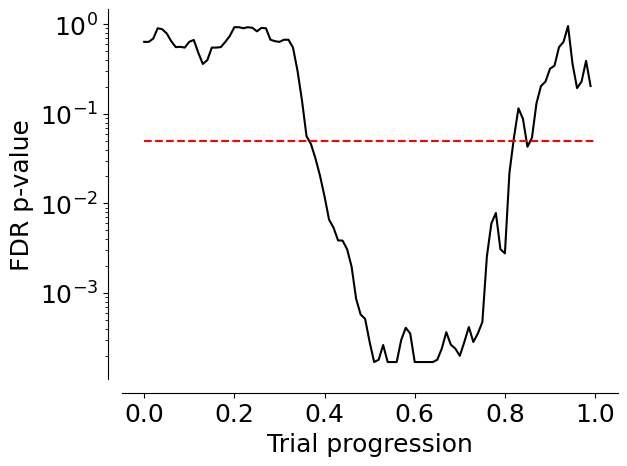

In [31]:
p_values = []
for i in velocity_df.trial_length.unique():
    section = velocity_df[velocity_df.trial_length == i]
    t = ttest_ind(
        section[section.aperture == section.aperture.unique()[0]].velocity,
        section[section.aperture == section.aperture.unique()[1]].velocity,
    )
    p_values.append(pd.DataFrame({"segment": i, "p_value": t.pvalue}, index=[0]))

p_value_df = pd.concat(p_values)
p_value_df["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

plt.plot(p_value_df.segment, p_value_df.p_value_corr, c="k")

plt.hlines(0.05, xmin=0, xmax=1, color="red", linestyle="dashed")

plt.xlabel("Trial progression")
plt.ylabel("FDR p-value")
plt.yscale("log")

sns.despine(offset=10)
plt.savefig(save_fig_path + "supp_contrast_velocity_pvalue.svg", transparent=True)

### Optimal p

In [32]:
# TODO This fecth call is a little slow, maybe we should add an optimal p table
optimal_df = []
for m in mouse_list:
    print(m)
    optimal_df.append(pd.DataFrame((InterpolatedTrials() & f'dataset="{m}"').fetch("dataset", "trial", "aperture", "optimal_p", as_dict=True)[0]))
optimal_df = pd.concat(optimal_df)

# Create list of included datasets
mouse_list = optimal_df.dataset.unique()
optimal_df["mouse_name"] = optimal_df.dataset.str.split("_").str [0]

optimal_df =  optimal_df.groupby(["dataset", "mouse_name", "trial", "aperture"], as_index=False).mean()
optimal_df =  optimal_df.groupby(["dataset", "mouse_name", "aperture"], as_index=False).mean()

Flamingo_2026-02-02_1
Flamingo_2026-02-03_1
Flamingo_2026-02-04_1
Flamingo_2026-02-05_1
Flamingo_2026-02-06_1
Flamingo_2026-02-09_1
Grizzly_2026-02-03_1
Grizzly_2026-02-04_1
Grizzly_2026-02-05_1
Grizzly_2026-02-09_1
Grizzly_2026-02-11_1
Hamster_2026-02-03_1
Hamster_2026-02-04_1
Hamster_2026-02-06_1
Hamster_2026-02-09_1


In [33]:
optimal_df["lab_id"] = 0
for dataset_name in mouse_list:
    # Fetch lab_id for each dataset
    optimal_df.loc[optimal_df.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

mean 4.3: 14.73409324511116
sem 4.3: 1.1211647591569753
12.0-4.3: TtestResult(statistic=-2.741191996403561, pvalue=0.015917849074639428, df=14)
mean 12.0: 13.210398985341383
sem 12.0: 0.9594091335646505


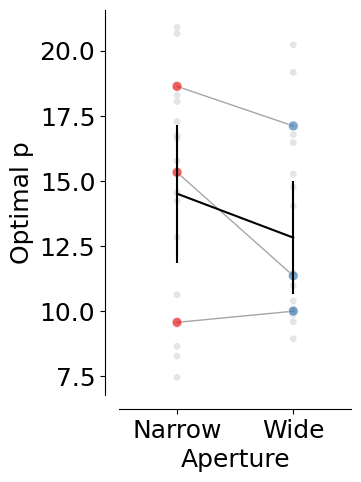

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))

counts = (
    optimal_df
    .groupby(["mouse_name", "dataset", "aperture"], as_index=False)
    .optimal_p.mean()
)

counts["count"] = counts["optimal_p"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax,
    per_mouse=True,
    cmap=plotting.colors_aperture[0:2],
)
ax.invert_xaxis()

ax.set_ylabel("Optimal p")
ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_xlabel("Aperture")

plt.legend([], [], frameon=False)
sns.despine(offset=10)

for i in counts.aperture.unique():
    for j in counts.aperture.unique():
        if i < j:
            stat = stats.ttest_rel(
                counts[counts["aperture"] == i]["optimal_p"],
                counts[counts["aperture"] == j]["optimal_p"],
            )
            print(f"{i}-{j}: {stat}")

    print(f"mean {i}: {np.mean(counts[counts['aperture'] == i]['optimal_p'])}")
    print(f"sem {i}: {stats.sem(counts[counts['aperture'] == i]['optimal_p'])}")
plt.savefig(save_fig_path + "supp_contrast_fitted_p.svg", transparent=True)

In [35]:
counts.groupby("aperture").optimal_p.mean(), counts.groupby("aperture").optimal_p.sem()

(aperture
 12.0    13.210399
 4.3     14.734093
 Name: optimal_p, dtype: float64,
 aperture
 12.0    0.959409
 4.3     1.121165
 Name: optimal_p, dtype: float64)

### Regression model

In [36]:
# This takes a while to fetch because we need to fetch data for all trials
dataset_list = []
for d in mouse_list:
    print(d)
    try:
        dataset_list.append(pd.DataFrame((InterpolatedTrials() & f'dataset = "{d}"').fetch(as_dict=True)[0]))
    except Exception as err:
        print(err, " dataset missing")
interpolated_df = pd.concat(dataset_list)
interpolated_df["mouse_name"] = interpolated_df.dataset.str.split("_").str[0]

Flamingo_2026-02-02_1


Flamingo_2026-02-03_1
Flamingo_2026-02-04_1
Flamingo_2026-02-05_1
Flamingo_2026-02-06_1
Flamingo_2026-02-09_1
Grizzly_2026-02-03_1
Grizzly_2026-02-04_1
Grizzly_2026-02-05_1
Grizzly_2026-02-09_1
Grizzly_2026-02-11_1
Hamster_2026-02-03_1
Hamster_2026-02-04_1
Hamster_2026-02-06_1
Hamster_2026-02-09_1


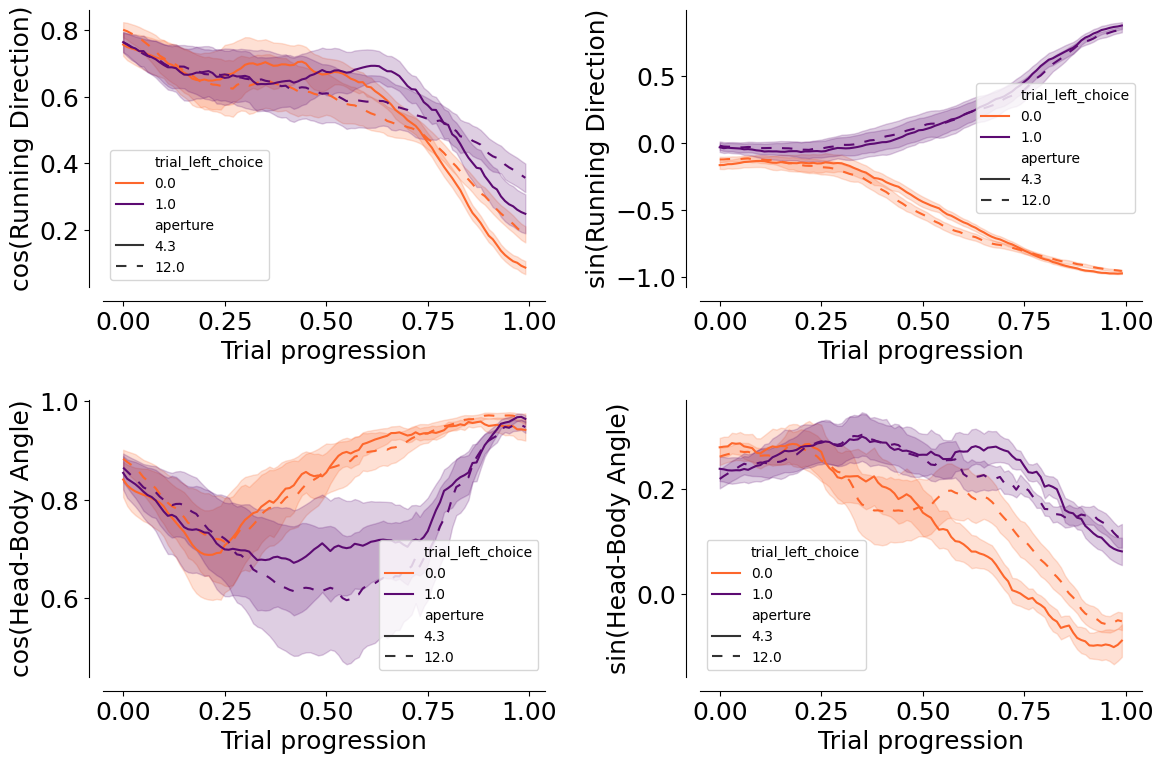

In [37]:
mean_mouse = interpolated_df.groupby(
    ["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False
).mean(numeric_only=True)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.flatten()

dash_styles = {
    mean_mouse.aperture.unique()[0]: "",         # Solid
    mean_mouse.aperture.unique()[1]: (5, 5)      # Dashed
}

for (i, label), label_str in zip(enumerate(
    ["heading_dir_cos", "heading_dir_sin", "head_angle_cos", "head_angle_sin"]
), ["cos(Running Direction)", "sin(Running Direction)", "cos(Head-Body Angle)", "sin(Head-Body Angle)"]):
    sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y=label,
        palette=plotting.colors_choice[::-1]
        if len(mean_mouse.aperture.unique()) == 2
        else "viridis",
        hue="trial_left_choice"
        if len(mean_mouse.aperture.unique()) == 2
        else "aperture",
        style=(
            "aperture"
            if len(mean_mouse.aperture.unique()) == 2
            else "trial_left_choice"
        ),
        dashes=dash_styles,
        errorbar="se",
        ax=ax[i],
    )
    ax[i].set_ylabel(label_str)
    ax[i].set_xlabel("Trial progression")
    sns.despine(ax=ax[i], offset=10)


plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "supp_contrast_heading_dir_head_angle_cos_sin.svg", bbox_inches="tight", transparent=True)

In [38]:
task_type_key = {"set_name": "contrast_black_target",
                 "stage_name": "dual_occlusion"}

In [39]:
model_key = {"label_set_id": 8, "params_id": 1}

In [40]:
# Coefficients for dual occluder task
coef = (PredictionModel() & model_key & task_type_key).fetch1("coefficients")

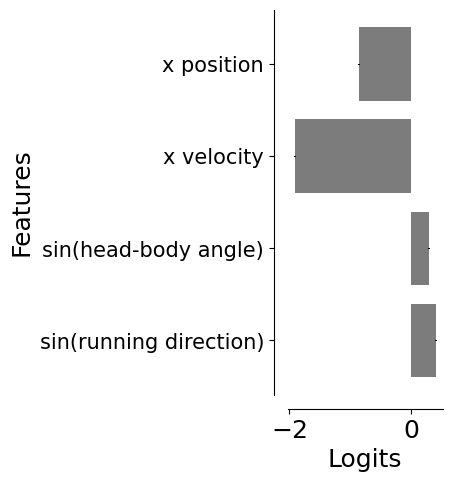

In [41]:
# Logits of the regression
model_labels, clean_labels = (LabelSet.Member * Label & model_key).fetch("label_key", "clean_name")

fig, ax = plt.subplots(1, 1, figsize=(2, 5))
ax.barh(
    model_labels,
    np.mean(coef[:, 1:], axis=0),
    yerr=stats.sem(coef[:, 1:], axis=0),
    color="#7C7C7C",
)
sns.despine(offset=10, ax=ax)

ax.set_yticks(np.arange(len(model_labels)))
ax.set_yticklabels(clean_labels, rotation=0, ha="right", fontsize=15)
ax.set_xlabel("Logits")
ax.set_ylabel("Features")

plt.savefig(save_fig_path + "supp_contrast_model_logits.svg", transparent=False)

In [42]:
prediction_df = pd.DataFrame((PredictionModel().SessionPrediction() & model_key & task_type_key).fetch(
    "dataset", "trial", "proba_left", "accuracy", "trial_length", as_dict=True)).explode(["trial", "proba_left", "accuracy", "trial_length"])

In [43]:
df_model = prediction_df.merge(
    interpolated_df[["dataset", "trial_length", "trial", "aperture", "trial_left_choice", "x", "y"]], on=["dataset", "trial", "trial_length"]
)

df_model["accuracy"] = df_model["accuracy"].astype(float)
df_model["proba_left"] = df_model["proba_left"].astype(float)

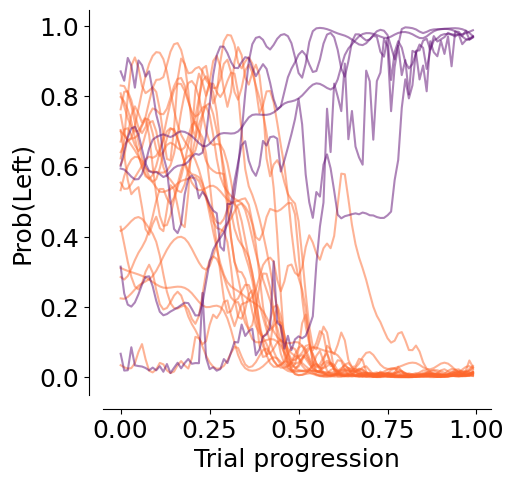

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

group = df_model[(df_model.dataset == "Flamingo_2026-02-09_1")]

trials = [
    94,
    15,
    66,
    170,
    224,
    195,
    56,
    203,
    88,
    239,
    113,
    91,
    186,
    248,
    109,
    164,
    188,
    60,
    229,
    182,
    156,
    197,
    52,
    45,
]

group = group[group.trial.isin(np.array(trials))]
sns.lineplot(
    data=group,
    x="trial_length",
    y="proba_left",
    hue="trial_left_choice",
    errorbar=None,
    estimator=None,
    units="trial",
    palette=plotting.colors_choice[::-1],
    sort=False,
    alpha=0.5,
    ax=ax,
)
ax.set_ylabel("Prob(Left)")
ax.set_xlabel("Trial progression")
ax.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(
    save_fig_path + "supp_contrast_dynamic_decision_variable.svg",
    transparent=True,
)

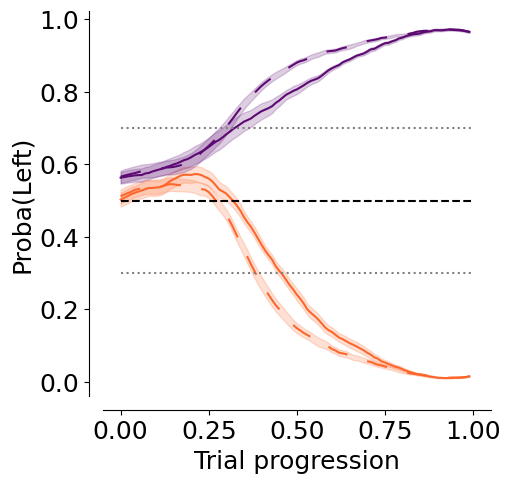

In [45]:
df_model_mean =  df_model.groupby(["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False).mean()
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

dash_styles = {
    mean_mouse.aperture.unique()[0]: "",         # Solid
    mean_mouse.aperture.unique()[1]: (10, 10)      # Dashed
}

sns.lineplot(
    data=df_model_mean,
    x="trial_length",
    y="proba_left",
    hue="trial_left_choice",
    style="aperture",
    palette=plotting.colors_choice[::-1],
    sort=False,
    alpha=1,
    ax=ax,
    errorbar="se",
    dashes=dash_styles
)
ax.set_ylabel("Proba(Left)")
ax.set_xlabel("Trial progression")

ax.hlines(0.5, xmin=0, xmax=1, colors="black", linestyles="dashed")
ax.hlines(0.7, xmin=0, xmax=1, colors="gray", linestyles="dotted")
ax.hlines(0.3, xmin=0, xmax=1, colors="gray", linestyles="dotted")
ax.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(
    save_fig_path + "supp_contrast_dynamic_decision_variable_avg.png",
    transparent=True,
    dpi=300,
)

plt.savefig(
    save_fig_path + "supp_contrast_dynamic_decision_variable_avg.svg",
    transparent=True,
)

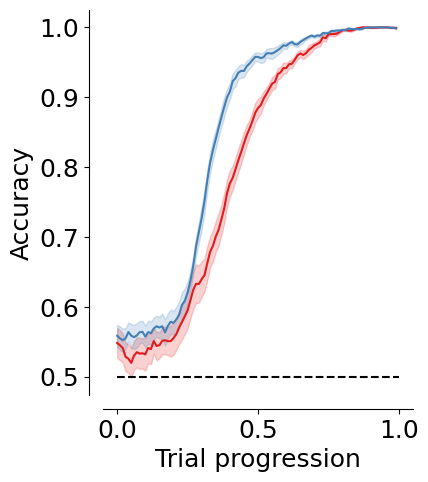

In [46]:
df_model_mean =  df_model.groupby(["dataset", "aperture", "trial_length"], as_index=False).mean()

fig, ax = plt.subplots(1, 1, figsize=(4, 5))
sns.lineplot(
    data=df_model_mean,
    x="trial_length",
    y="accuracy",
    hue="aperture",
    palette=plotting.colors_aperture,
    sort=False,
    alpha=1,
    ax=ax,
    errorbar="se"
)
ax.hlines(0.5, 0, 1, color="black", linestyle="--")

ax.set_ylabel("Accuracy")
ax.set_xlabel("Trial progression")
ax.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(
    save_fig_path + "supp_contrast_model_accuracy.svg", transparent=True
)

In [47]:
decision_points = pd.DataFrame((DecisionPoints() & task_type_key & model_key & "threshold_uncertainty = 0.2").fetch(as_dict=True))
decision_points = decision_points.explode(["trial", "aperture", "trial_length", "trial_left_choice", "proba_left", "x", "y", "trial_rewarded"])
decision_points["mouse_name"] = decision_points.dataset.str.split("_").str[0]

In [50]:
with open("information_maps/data/info_matrix_unnormalized_12.3w.npy", "rb") as file:
    info_matrix_narrow = np.rot90(np.load(file), k=1)
with open("information_maps/data/info_matrix_unnormalized_34.6w.npy", "rb") as file:
    info_matrix_wide = np.rot90(np.load(file), k=1)

info_matrices = [info_matrix_narrow, info_matrix_wide]

# normalize info matrices to max 1
info_matrices = [im / im.max() for im in info_matrices]

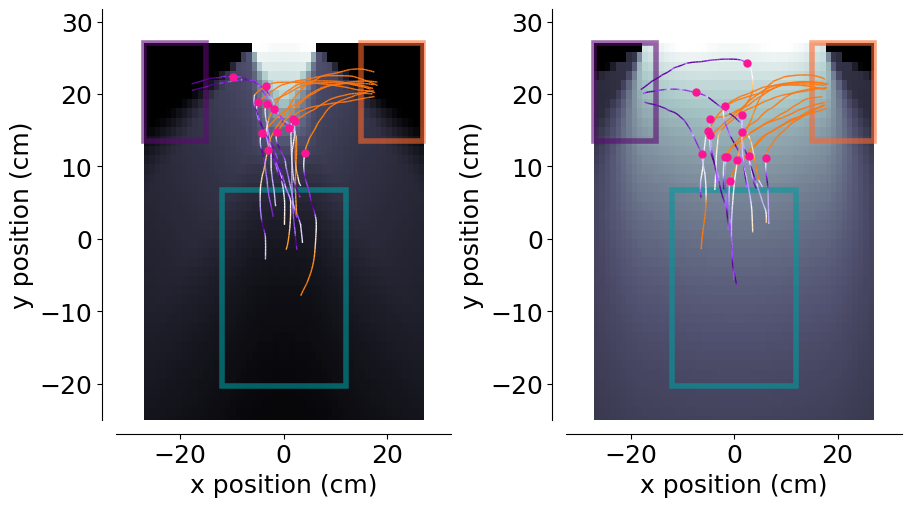

In [51]:
fig, ax = plt.subplots(
    1, len(df_model.aperture.unique()), figsize=(9, 5), constrained_layout=True
)

decision_color = "deeppink"
session_to_plot = "Flamingo_2026-02-09_1"

trials = [44, 45, 19, 62, 61, 45, 85, 41, 43, 41, 50, 75, 24, 69, 84, 74, 10] + [
    63,
    30,
    78,
    47,
    33,
    5,
    17,
    9,
    47,
    30,
    99,
    11,
    12,
    15,
]

# Start from PuOr
base_cmap = cm.get_cmap("PuOr")

# Make a brighter version by rescaling luminance
def brighten(cmap, factor=2):
    colors = cmap(np.linspace(0, 1, 256))
    rgb = mcolors.rgb_to_hsv(colors[:, :3])
    rgb[:, 2] = rgb[:, 2] * factor  # brighten value channel
    rgb[:, 2] = np.clip(rgb[:, 2], 0, 1)
    colors[:, :3] = mcolors.hsv_to_rgb(rgb)
    return mcolors.ListedColormap(colors)

bright_puor = brighten(base_cmap)

for i, aperture in enumerate(df_model.aperture.unique()[::-1]):
    regression.plot_decision_points_on_trajectory(
        df_model[
            (df_model.dataset == session_to_plot) & (df_model.aperture == aperture)
        ],
        box_df,
        decision_point=decision_points[
            (decision_points.dataset == session_to_plot)
            & (decision_points.aperture == aperture)
        ],
        color=decision_color,
        trials=trials,
        ax=ax[i],
        cmap=bright_puor,
    )
    
    xlim = ax[i].get_xlim()
    ylim = ax[i].get_ylim()

    im = ax[i].imshow(info_matrices[i], 
                 cmap="bone", 
                 extent=[-27, 27, -27, 27],
                 zorder=-10)
    
    ax[i].set_xlim(xlim)
    ax[i].set_ylim(ylim)
    ax[i].set_aspect(1.4)
    ax[i].set_xlabel("x position (cm)")
    ax[i].set_ylabel("y position (cm)")
    sns.despine(offset=10, ax=ax[i])

#fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.03, pad=0.04, label="Information content rate")
plt.savefig(
    save_fig_path + "supp_contrast_decision_points_trajectories_bright.svg",
    transparent=True,
)

mean: 13.86564617811223 +/- 0.5386939023469558
12.0-4.3: TtestResult(statistic=-4.592982876939882, pvalue=0.00041800924735993993, df=14)
 mean difference:  3.6491137828863707
mean: 10.21653239522586 +/- 0.4492331557704968


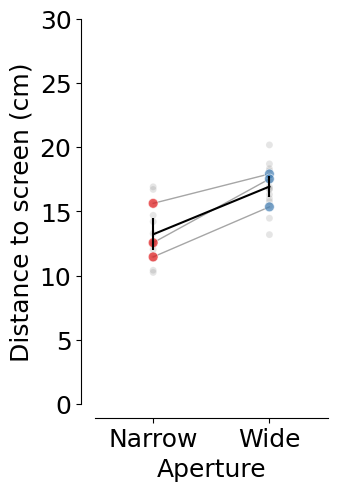

In [52]:
decision_points["y"] = decision_points.y.astype(float)

fig, ax = plt.subplots(1, 1, figsize=(3, 5))
stats_res = plotting.pairplot_average_decision_point(
    decision_points,
    label_parameter="y",
    ax=ax,
    cmap=plotting.colors_aperture,
    per_mouse=True,
)
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, 30)
ax.set_xlabel("Aperture")
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_ylabel("Distance to screen (cm)")
sns.despine(offset=10)
plt.legend([], [], frameon=False)

plt.savefig(
    save_fig_path + "supp_contrast_decision_points_distance.svg",
    transparent=True,
)

### Direct comparison

In [53]:
trial_df_white = (TrialMetrics() * vr4mice.Groups() * vr4mice.Labels() * (vr4mice.Dataset() & 'session_label = "ar_discrim_occluders"')).fetch(as_dict=True)
trial_df_white =  pd.concat([pd.DataFrame(x) for x in trial_df_white])

# Exclude sessions that were not in the list
trial_df_white, reward_table = utils.apply_inclusion_criteria(trial_df_white,
                                                        return_excluded=False)

# Create list of included datasets
mouse_list_white = trial_df_white.dataset.unique()
trial_df_white["mouse_name"] = trial_df_white.dataset.str.split("_").str[0]

In [54]:
y_binned_df_white = []
for m in mouse_list_white:
    try:
        y_binned_df_white.append(pd.DataFrame((InterpolatedTrials() & f'dataset="{m}"').fetch("dataset", "aperture", "trial", "x", "y", "flip_one_side", "trial_left_choice", as_dict=True)[0]))
    except Exception as err:
        print(err)
y_binned_df_white = pd.concat(y_binned_df_white)

In [55]:
y_binned_df_white["mouse_name"] = y_binned_df_white.dataset.str.split("_").str [0]
y_binned_df_white["x_flipped"] = y_binned_df_white.x * y_binned_df_white.flip_one_side
y_binned_df_white_mean = analysis.mean_xy_trajectory(utils.create_bins(y_binned_df_white,
                                                                  spatial_ybins=[-13, 24, 30]), index_columns= ["dataset", "mouse_name", "aperture", "bin_centers"], values=["x_flipped", "y"])

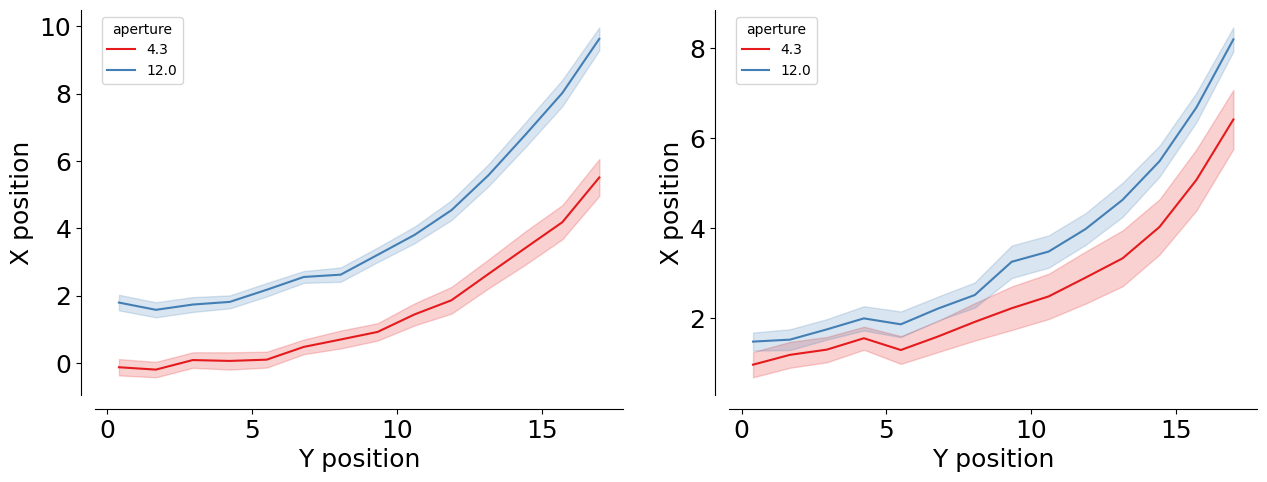

In [56]:
stats_binned_white = y_binned_df_white_mean[(y_binned_df_white_mean.bin_centers >= 0) & (y_binned_df_white_mean.bin_centers <= 18)]
stats_binned = y_binned_df_mean[(y_binned_df_mean.bin_centers >= 0) & (y_binned_df_mean.bin_centers <= 18)]

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(data = stats_binned_white, x="bin_centers", y="x_flipped", hue="aperture", 
             palette= plotting.colors_aperture, errorbar="se", ax=ax[0])
ax[0].set_xlabel("Y position")
ax[0].set_ylabel("X position")


sns.lineplot(data = stats_binned, x="bin_centers", y="x_flipped", hue="aperture", 
             palette= plotting.colors_aperture, errorbar="se", ax=ax[1])
ax[1].set_xlabel("Y position")
ax[1].set_ylabel("X position")

sns.despine(offset=10)

In [57]:
p_values_white = []
for i in stats_binned_white.bin_centers.unique():
    section = stats_binned_white[stats_binned_white.bin_centers == i]
    t = ttest_rel(
        section[section.aperture == section.aperture.unique()[0]].x_flipped,
        section[section.aperture == section.aperture.unique()[1]].x_flipped,
    )
    p_values_white.append(pd.DataFrame({"segment": i, "p_value": t.pvalue}, index=[0]))

p_value_df_white = pd.concat(p_values_white)
p_value_df_white["p_value_corr"] = stats.false_discovery_control(p_value_df_white.p_value)

In [58]:
# Assign labels
stats_binned_white['source'] = 1
stats_binned['source'] = 0

# Vertical append
df_combined = pd.concat([stats_binned_white, stats_binned], ignore_index=True)

In [59]:
def calculate_cohen_d(group0, group1):
    """Calculates Cohen's d for two independent samples."""
    n0, n1 = len(group0), len(group1)
    # Degrees of freedom
    dof = n0 + n1 - 2
    # Pooled Standard Deviation
    # Using ddof=1 for unbiased variance estimate
    var0 = np.var(group0, ddof=1)
    var1 = np.var(group1, ddof=1)
    pooled_std = np.sqrt(((n0 - 1) * var0 + (n1 - 1) * var1) / dof)
    
    # Calculate d (difference of means over pooled std)
    if pooled_std == 0:
        return 0
    return (np.mean(group0) - np.mean(group1)) / pooled_std

comp_rows = []
for (ap, b), g in df_combined.groupby(["aperture", "bin_centers"]):
    vals_0 = g[g["source"] == 0]["x_flipped"].dropna()
    vals_1 = g[g["source"] == 1]["x_flipped"].dropna()
    
    # Increased minimum N to 3 for slightly better stability
    if len(vals_0) < 3 or len(vals_1) < 3:
        continue
        
    # Welch's t-test (handles unequal variance and unequal n)
    t_res = stats.ttest_ind(vals_0, vals_1, equal_var=False)
    
    # Cohen's d for effect size
    d_val = calculate_cohen_d(vals_0, vals_1)
    
    comp_rows.append(
        {
            "aperture": ap,
            "bin_centers": b,
            "n_source0": len(vals_0),
            "n_source1": len(vals_1),
            "t_stat": t_res.statistic,
            "p_value": t_res.pvalue,
            "cohen_d": d_val
        }
    )

per_bin_results = pd.DataFrame(comp_rows).sort_values(["aperture", "bin_centers"])

if not per_bin_results.empty:
    # FDR correction within each aperture
    per_bin_results["p_value_corr"] = (
        per_bin_results.groupby("aperture")["p_value"]
        .transform(lambda s: stats.false_discovery_control(s))
    )
    per_bin_results["significant"] = per_bin_results["p_value_corr"] < 0.05

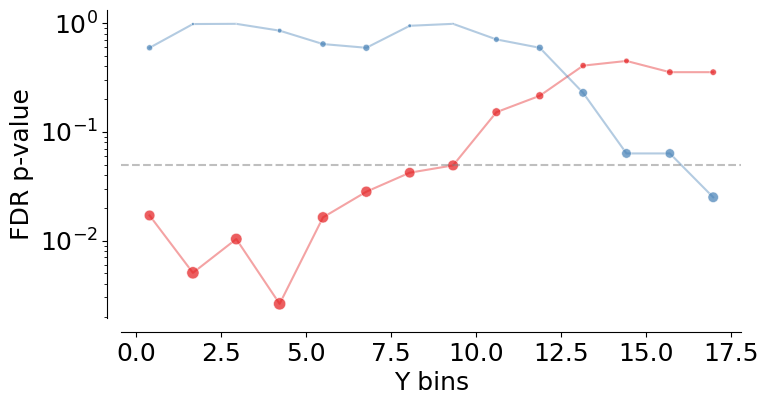

In [60]:
# Plot the p-values across bins for each aperture
apertures_sorted = sorted(per_bin_results["aperture"].unique())
colors = plotting.colors_aperture[:len(apertures_sorted)]
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

for ap, color in zip(apertures_sorted, colors):
    sub = per_bin_results[per_bin_results["aperture"] == ap]
    
    ax.plot(sub["bin_centers"], 
            sub["p_value_corr"], 
            color=color, 
            linewidth=1.5, 
            label=f"Aperture {ap}",
            alpha=0.4,
            zorder=1
            )
    
    ax.scatter(
        sub["bin_centers"],
        sub["p_value_corr"],
        color=color,
        s=sub["cohen_d"].abs() * 80, 
        alpha=0.7,
        edgecolor="white",
        linewidths=0.5,
        zorder=2
    )

# Significance threshold
ax.axhline(0.05, linestyle="--", color="grey", alpha=0.5)

# Formatting
ax.set_ylabel("FDR p-value")
ax.set_xlabel("Y bins")
ax.set_yscale('log')

sns.despine(ax=ax, offset=10)
plt.savefig(save_fig_path + "supp_contrast_position_p_values_with_effect_size.svg", transparent=True)

## Multi-session analysis

In [61]:
trial_df = ((vr4mice.Dataset() & 'session_label = "ar_discrim_5_occluders_inv"') * TrialMetrics()).fetch(as_dict=True)
trial_df = pd.concat([pd.DataFrame(x) for x in trial_df])
trial_df ["aperture"] = trial_df.aperture.round(2)
trial_df, reward_table = utils.apply_inclusion_criteria(trial_df[["dataset", "aperture", "trial", "trial_left_choice", "trial_rewarded", "trial_tortuosity", "trial_duration"]],
                                                        return_excluded=False)

# Create list of included datasets
sessions_list = trial_df.dataset.unique()
trial_df["mouse_name"] = trial_df.dataset.str.split("_").str [0]

In [62]:
trial_df.mouse_name.nunique(), trial_df.dataset.nunique()

(3, 10)

In [63]:
trial_df.groupby("mouse_name").nunique().dataset

mouse_name
Flamingo    4
Grizzly     3
Hamster     3
Name: dataset, dtype: int64

In [64]:
trial_df.dataset.unique()

array(['Flamingo_2026-02-12_1', 'Flamingo_2026-02-16_1',
       'Flamingo_2026-02-17_1', 'Flamingo_2026-02-18_1',
       'Grizzly_2026-02-13_1', 'Grizzly_2026-02-17_1',
       'Grizzly_2026-02-19_1', 'Hamster_2026-02-11_1',
       'Hamster_2026-02-17_1', 'Hamster_2026-02-18_1'], dtype=object)

In [65]:
trial_df["lab_id"] = 0
for dataset_name in sessions_list:
    # Fetch lab_id for each dataset
    trial_df.loc[trial_df.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

                Anova
         F Value Num DF  Den DF Pr > F
--------------------------------------
aperture  0.2444 4.0000 36.0000 0.9112



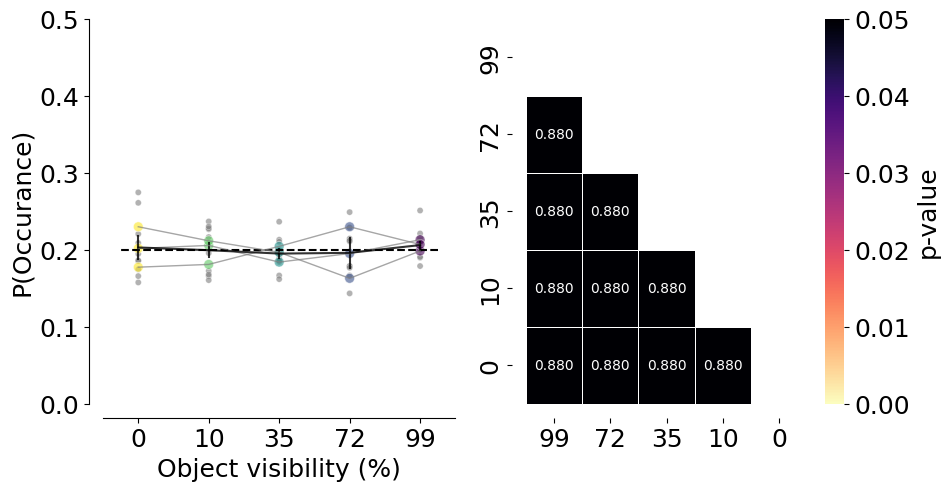

In [ ]:
# Occurance of the different conditions
counts = (
    trial_df.groupby(["dataset", "mouse_name", "aperture"])
    .trial.nunique()
    .reset_index(name="trial_count")
)
total_trials = (
    trial_df.groupby("dataset").trial.nunique().reset_index(name="total_trials")
)

counts = counts.merge(total_trials, on="dataset")
counts["probability"] = counts["trial_count"] / counts["total_trials"]
counts["aperture"] = counts["aperture"].astype("float")
counts = counts.sort_values("aperture")

counts["aperture_numeric"] = counts["aperture"]
aperture_order = counts["aperture"].unique()
counts["aperture"] = pd.Categorical(counts["aperture"].astype("str"), categories=aperture_order.astype("str"), ordered=True)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    units="mouse_name",
    estimator=None,
    color="grey",
    alpha=0.7,
    linewidth=1,
    zorder=3,
    ax=ax[0]
)

sns.scatterplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    hue="aperture",
    palette=plotting.colors_multi_aperture[::-1],
    alpha=0.6,
    s=50,
    zorder=2,
    ax=ax[0]
)

sns.scatterplot(
    data=counts,
    x="aperture",
    y="probability",
    hue="aperture",
    palette=["grey"] * counts["dataset"].nunique(),
    alpha=0.6,
    zorder=1,
    s=20,
    ax=ax[0]
)

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    color="black",
    err_style="bars",
    errorbar="se",
    alpha=0.8,
    zorder=4,
    ax=ax[0]
)

ax[0].hlines(
    0.2,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

ax[0].set_ylim(0, .5)
ax[0].set_xlim(-0.5, 4.5)
ax[0].invert_xaxis()

ax[0].set_xticks([4, 3, 2, 1, 0], ["0", "10", "35", "72", "99"])

ax[0].set_xlabel("Object visibility (%)")
ax[0].set_ylabel("P(Occurance)")
sns.despine(offset=10)
ax[0].legend([], [], frameon=False)

# Use numeric aperture for statistical analysis
counts_for_stats = counts.copy()
counts_for_stats['aperture'] = counts_for_stats['aperture_numeric']
p_values = get_multi_p_values_global(counts_for_stats,  y_var="probability")
plot_aperture_heatmap(p_values, ax= ax[1])
ax[1].set_xticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])
ax[1].set_yticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])

print(AnovaRM(counts_for_stats, depvar="probability", subject="dataset", within=["aperture"]).fit())

plt.savefig(save_fig_path + "Supp_contrast_occurance.svg", transparent=True)

3.0-4.2: TtestResult(statistic=-2.393581489543188, pvalue=0.04031995582024074, df=9)
3.0-6.0: TtestResult(statistic=-4.828195259656327, pvalue=0.0009362490311677638, df=9)
3.0-8.48: TtestResult(statistic=-8.912242575011279, pvalue=9.249971086695045e-06, df=9)
3.0: mean=0.741 ± 0.019
4.2-6.0: TtestResult(statistic=-1.92096579756734, pvalue=0.08692191216160115, df=9)
4.2-8.48: TtestResult(statistic=-4.850135306839086, pvalue=0.0009081641543759242, df=9)
4.2: mean=0.825 ± 0.030
6.0-8.48: TtestResult(statistic=-1.6376979753432979, pvalue=0.13590988416235417, df=9)
6.0: mean=0.906 ± 0.021
8.48: mean=0.961 ± 0.016
12.0-3.0: TtestResult(statistic=7.563845984282052, pvalue=3.4542138680018426e-05, df=9)
12.0-4.2: TtestResult(statistic=4.649208855191627, pvalue=0.0012034624661946347, df=9)
12.0-6.0: TtestResult(statistic=1.4393108531069605, pvalue=0.1839202289289116, df=9)
12.0-8.48: TtestResult(statistic=-0.8155525627147091, pvalue=0.43580720509681725, df=9)
12.0: mean=0.944 ± 0.016
           

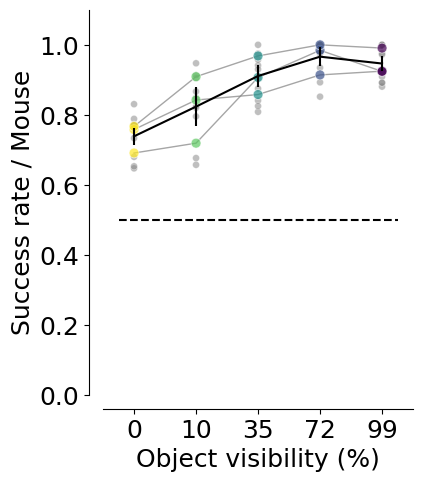

In [ ]:
# Success rate per mouse
fig, ax = plt.subplots(1, 1, figsize=(4, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_multi_aperture,
    per_mouse=True,
)
ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

ax.set_ylim(0, 1.1)
ax.set_xlim(-0.5, 4.5)
ax.set_xlabel("Object visibility (%)")
ax.set_ylabel("Success rate / Mouse")
ax.set_xticks([0, 1, 2, 3, 4], ["0", "10", "35", "72", "99"])

ax.legend([], [], frameon=False)
sns.despine(offset=10)

print(AnovaRM(counts_for_stats, depvar="probability", subject="dataset", within=["aperture"]).fit())

plt.savefig(save_fig_path + "Supp_contrast_rewards_per_mouse.svg", transparent=True)

3.0-4.2: TtestResult(statistic=-3.234131923327639, pvalue=0.01025455884314167, df=9)
3.0-6.0: TtestResult(statistic=-5.383118385251004, pvalue=0.0004426822155233248, df=9)
3.0-8.48: TtestResult(statistic=-8.116380148217551, pvalue=1.9718939437404885e-05, df=9)
3.0: mean=0.741 ± 0.019
4.2-6.0: TtestResult(statistic=-2.2355372934526856, pvalue=0.0522224797428455, df=9)
4.2-8.48: TtestResult(statistic=-3.865270064925998, pvalue=0.0038162261690114427, df=9)
4.2: mean=0.825 ± 0.030
6.0-8.48: TtestResult(statistic=-4.255456977502932, pvalue=0.002125317377391665, df=9)
6.0: mean=0.906 ± 0.021
8.48: mean=0.961 ± 0.016
12.0-3.0: TtestResult(statistic=13.421219262892725, pvalue=2.9518244364314835e-07, df=9)
12.0-4.2: TtestResult(statistic=4.188771278438017, pvalue=0.0023453847116599253, df=9)
12.0-6.0: TtestResult(statistic=2.040598614017328, pvalue=0.07169567685267667, df=9)
12.0-8.48: TtestResult(statistic=-1.0546499929256126, pvalue=0.3190739239181713, df=9)
12.0: mean=0.944 ± 0.016
         

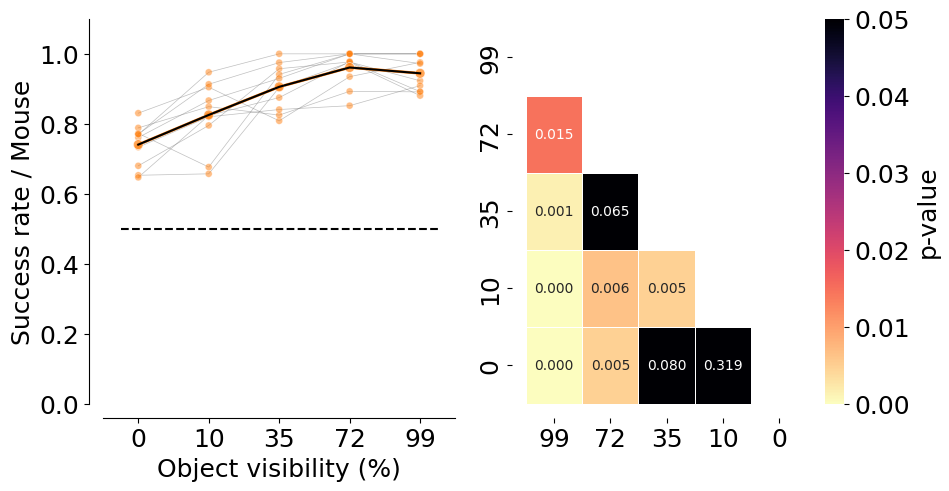

In [ ]:
# Success rate per mouse
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax[0],
    cmap=plotting.colors_multi_aperture,
    per_lab=True,
)
ax[0].hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

ax[0].set_ylim(0, 1.1)
ax[0].set_xlim(-0.5, 4.5)
ax[0].set_xlabel("Object visibility (%)")
ax[0].set_ylabel("Success rate / Mouse")
ax[0].set_xticks([0, 1, 2, 3, 4], ["0", "10", "35", "72", "99"])

ax[0].legend([], [], frameon=False)
sns.despine(offset=10)

p_values = get_multi_p_values_global(trial_df, y_var="trial_rewarded")
plot_aperture_heatmap(p_values, ax=ax[1])
ax[1].set_xticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])
ax[1].set_yticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])

mean_mouse = trial_df.groupby(["dataset", "aperture"], as_index=False).mean(numeric_only=True)
print(AnovaRM(mean_mouse, depvar="trial_rewarded", subject="dataset", within=["aperture"]).fit())

plt.savefig(save_fig_path + "Supp_contrast_rewards.svg", transparent=True)

3.0-4.2: TtestResult(statistic=-0.3096211581005676, pvalue=0.7638977890732921, df=9)
3.0-6.0: TtestResult(statistic=0.29635402461087895, pvalue=0.7736845197976516, df=9)
3.0-8.48: TtestResult(statistic=0.4672705396892659, pvalue=0.6514127323107162, df=9)
3.0: mean=0.118 ± 0.076
4.2-6.0: TtestResult(statistic=1.4186885408959362, pvalue=0.18967744578924367, df=9)
4.2-8.48: TtestResult(statistic=0.9773280577055755, pvalue=0.35394401899382844, df=9)
4.2: mean=0.149 ± 0.037
6.0-8.48: TtestResult(statistic=0.06095542942940637, pvalue=0.9527268563132709, df=9)
6.0: mean=0.084 ± 0.049
8.48: mean=0.079 ± 0.053
12.0-3.0: TtestResult(statistic=-2.0902928393997864, pvalue=0.06615191223045058, df=9)
12.0-4.2: TtestResult(statistic=-2.7132621916965687, pvalue=0.023869664597574187, df=9)
12.0-6.0: TtestResult(statistic=-1.9862311923302967, pvalue=0.07827032364343639, df=9)
12.0-8.48: TtestResult(statistic=-1.933169292278888, pvalue=0.08523822277235812, df=9)
12.0: mean=-0.076 ± 0.061
3.0-4.2: TtestRe

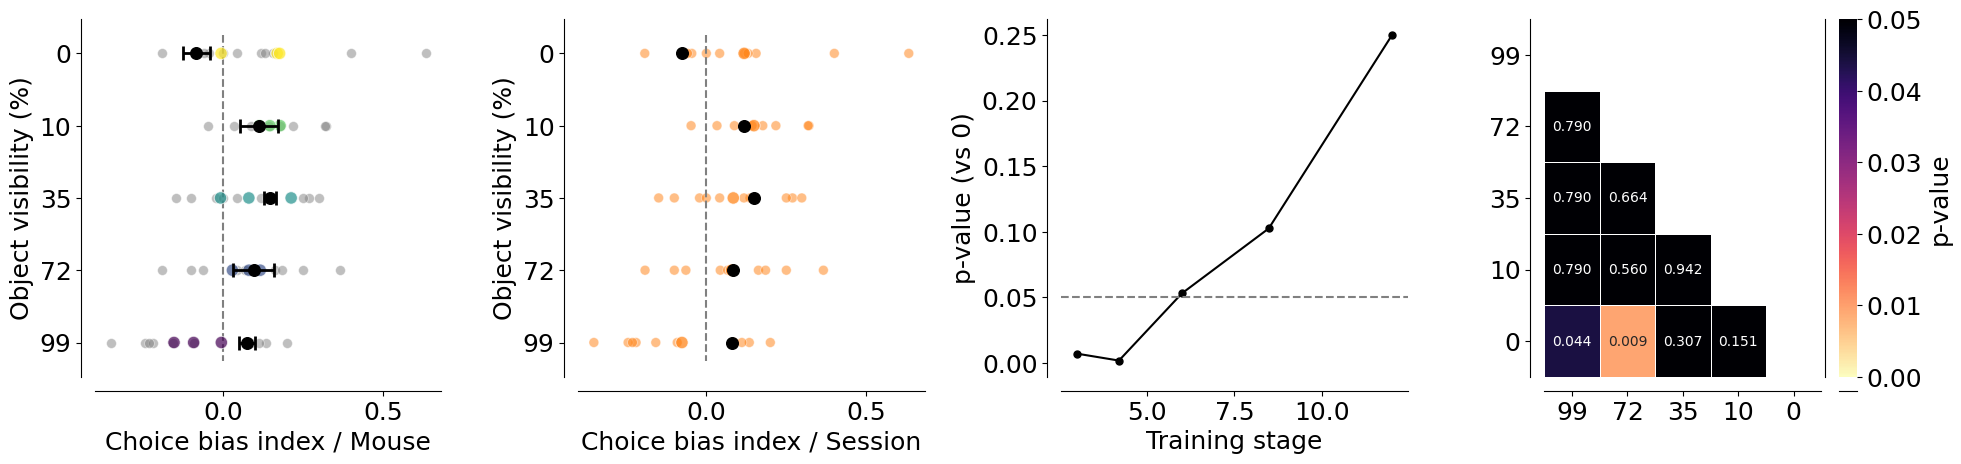

In [ ]:
trial_df["trial_bias"] = 2 * trial_df["trial_left_choice"] - 1 

# Choice bias per mouse and per lab
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_left_choice",
    plot_bias=True,
    per_aperture=True,
    ax=ax[0],
    cmap=plotting.colors_multi_aperture,
    per_mouse=True,
)
ax[0].vlines(
    0,
    ymin=-0.25,
    ymax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="grey",
)

ax[0].set_ylabel("Object visibility (%)")
ax[0].set_xlabel("Choice bias index / Mouse")
ax[0].set_yticks([0, 1, 2, 3, 4], ["0", "10", "35", "72", "99"])

ax[0].legend([], [], frameon=False)
sns.despine(offset=10)

plotting.plot_rate(
    df=trial_df,
    label_x="trial_left_choice",
    per_aperture=True,
    plot_bias=True,
    ax=ax[1],
    cmap=plotting.colors_multi_aperture,
    per_lab=True,
)
ax[1].vlines(
    0,
    ymin=-0.25,
    ymax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="grey",
)

ax[1].set_ylabel("Object visibility (%)")
ax[1].set_xlabel("Choice bias index / Session")
ax[1].set_yticks([0, 1, 2, 3, 4], ["0", "10", "35", "72", "99"])

ax[1].legend([], [], frameon=False)

# One-sample t-test of bias against 0 (null) per training stage
apertures_ = []
for stage in sorted(trial_df.aperture.unique()):
    vals = trial_df.loc[trial_df.aperture == stage, "trial_bias"]
    t_stat, p_val = stats.ttest_1samp(vals, 0)
    apertures_.append({
        "aperture": stage,
        "n": len(vals),
        "mean_bias": vals.mean(),
        "t_stat": t_stat,
        "df": max(len(vals) - 1, 0),
        "p_value": p_val,
    })
apertures_df = pd.DataFrame(apertures_)
print("One-sample t-tests vs 0 (bias)")
print(apertures_df)

# Plot p-values only (no bar/box)
ax[2].plot(apertures_df["aperture"], apertures_df["p_value"], 
           marker="o", linestyle="-", color="k")
ax[2].axhline(0.05, color="grey", linestyle="--")
ax[2].set_xlabel("Training stage")
ax[2].set_ylabel("p-value (vs 0)")

# Plot p-values of the multi-comparison test
p_values = get_multi_p_values_global(trial_df, y_var="trial_bias")
plot_aperture_heatmap(p_values, ax=ax[3])
ax[3].set_xticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])
ax[3].set_yticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])

mean_mouse = trial_df.groupby(["dataset", "aperture"], as_index=False).mean(numeric_only=True)
print(AnovaRM(mean_mouse, depvar="trial_bias", subject="dataset", within=["aperture"]).fit())

sns.despine(offset=10)
plt.tight_layout(pad=2)

plt.savefig(save_fig_path + "Supp_contrast_choice_bias.svg", transparent=True)

                Anova
         F Value Num DF  Den DF Pr > F
--------------------------------------
aperture  3.7683 4.0000 36.0000 0.0116



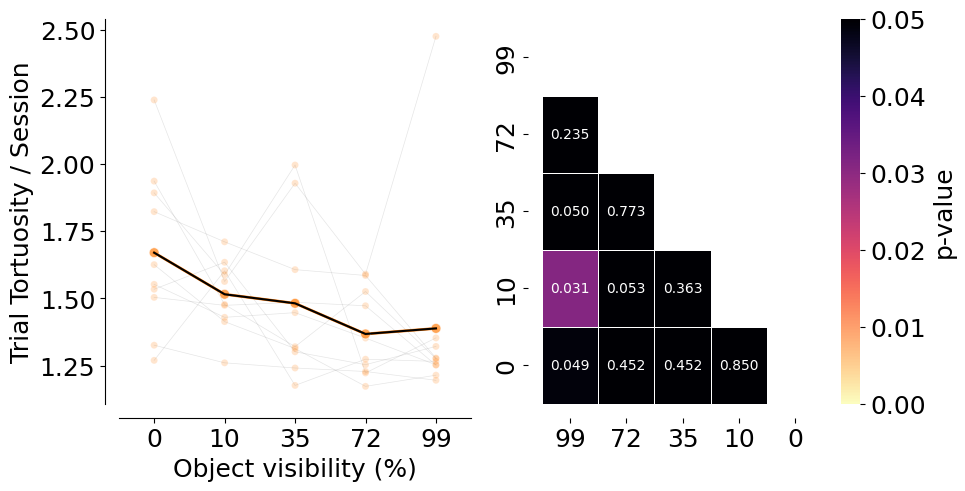

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

counts = (
    trial_df
    .groupby(["lab_id", "dataset", "aperture"], as_index=False)
    .trial_tortuosity.mean()
)

counts["count"] = counts["trial_tortuosity"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax[0],
    per_lab=True,
    cmap=plotting.colors_aperture[0:2],
)
ax[0].invert_xaxis()

ax[0].set_xlim(-0.5, 4.5)
ax[0].set_xlabel("Object visibility (%)")
ax[0].set_ylabel("Trial Tortuosity / Session")
ax[0].set_xticks([0, 1, 2, 3, 4], ["0", "10", "35", "72", "99"])

ax[0].legend([], [], frameon=False)
sns.despine(offset=10)

p_values = get_multi_p_values_global(trial_df,  y_var="trial_tortuosity")
plot_aperture_heatmap(p_values, ax=ax[1])
ax[1].set_xticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])
ax[1].set_yticks([4.5, 3.5, 2.5, 1.5, 0.5], ["0", "10", "35", "72", "99"])

mean_mouse = trial_df.groupby(["dataset", "aperture"], as_index=False).mean(numeric_only=True)
print(AnovaRM(mean_mouse, depvar="trial_tortuosity", subject="dataset", within=["aperture"]).fit())

plt.savefig(save_fig_path + "Supp_contrast_tortuosity.svg", transparent=True)

# Trajectory analysis

In [84]:
xy_df = []
for m in sessions_list:
    xy_df.append(pd.DataFrame((MeanXYTrajectory() & f'dataset="{m}"').fetch(as_dict=True)[0]))
xy_df = pd.concat(xy_df)
xy_df["mouse_name"] = xy_df.dataset.str.split("_").str [0]

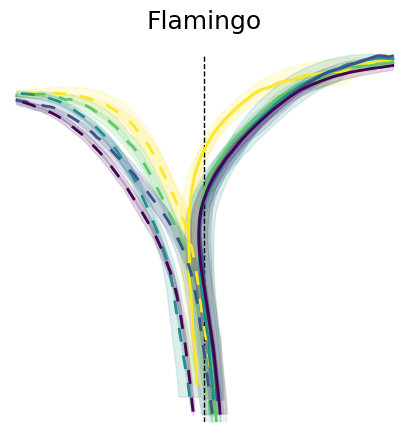

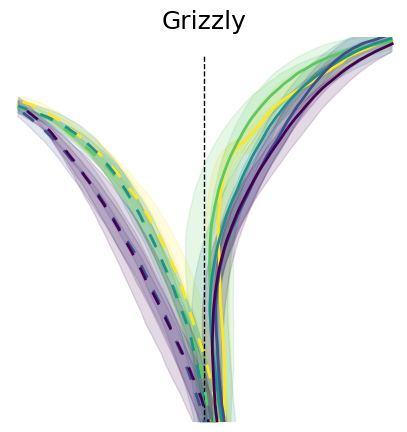

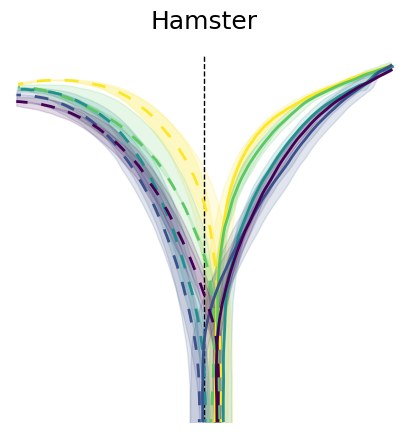

In [ ]:
# Mean and error by mouse
mean_mouse = analysis.mean_xy_trajectory(xy_df,
                                         index_columns=[
                                             "mouse_name", "aperture", "trial_left_choice", "trial_length"
                                         ])

for m in mean_mouse.mouse_name.unique():
    plotting.plot_mean_xy_trajectory(mean_mouse[mean_mouse.mouse_name == m], cmap=plt.cm.viridis_r, color_by="aperture", style_by="choice")
    plt.title(m)
    plt.savefig(save_fig_path + f"Supp_contrast_trajectories_time_{m}.svg", transparent=True)
    plt.savefig(save_fig_path + f"Supp_contrast_trajectories_time_{m}.png", transparent=True, dpi=300)

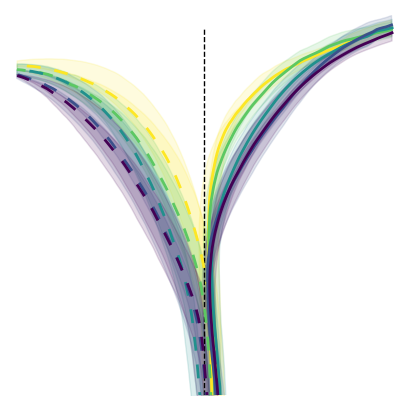

In [ ]:
# Mean and error by aperture and choice
mean_group = analysis.mean_xy_trajectory(mean_mouse, 
                                         index_columns=[
                                             "aperture",  "trial_left_choice", "trial_length"
                                         ])

# Plot the mean trajectories from 0, 23 cm in y axis, -18, 18 cm in x axis, colored by choice and styled by aperture
plotting.plot_mean_xy_trajectory(mean_group, cmap=plt.cm.viridis_r, color_by="aperture", style_by="choice")

plt.savefig(save_fig_path + "Supp_contrast_trajectories_time.svg", transparent=True)
plt.savefig(save_fig_path + "Supp_contrast_trajectories_time.png", transparent=True, dpi=300)

# Stats on trajectories

In [87]:
y_binned_df = []
for m in sessions_list:
    try:
        y_binned_df.append(pd.DataFrame((InterpolatedTrials() & f'dataset="{m}"').fetch("dataset", "aperture", "trial", "trial_left_choice", "x", "y", "flip_one_side", "trial_rewarded", "velocity", "trial_length", as_dict=True)[0]))
    except Exception as err:
        print(err)
y_binned_df = pd.concat(y_binned_df)

In [88]:
aperture_to_occlusion = {
    12.0: 99,
    8.48: 72,
    6.0: 35,
    4.2: 10,
    3.0: 0
}

y_binned_df["aperture"] = y_binned_df["aperture"].map(aperture_to_occlusion)
y_binned_df["mouse_name"] = y_binned_df.dataset.str.split("_").str [0]
y_binned_df["x_flipped"] = y_binned_df.x * y_binned_df.flip_one_side
data = utils.create_bins(y_binned_df)
y_binned_df_mean = analysis.mean_xy_trajectory(data, index_columns= ["dataset", "mouse_name", "aperture", "bin_centers"], values=["x_flipped", "y"])

                        Anova
                     F Value   Num DF  Den DF  Pr > F
-----------------------------------------------------
aperture               4.2511  4.0000  36.0000 0.0064
bin_centers          135.8912 24.0000 216.0000 0.0000
aperture:bin_centers   1.0311 96.0000 864.0000 0.4042



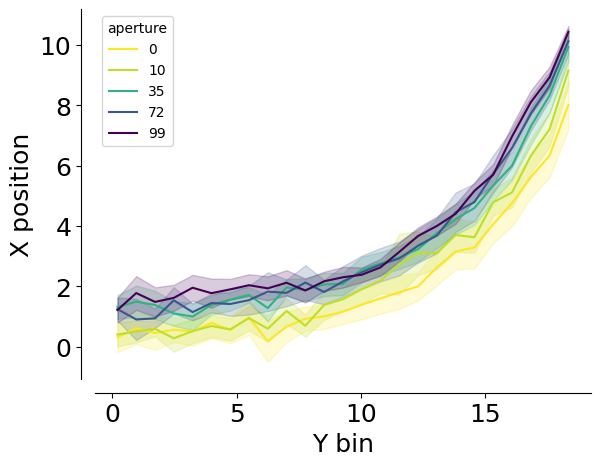

In [ ]:
# NOTE(celia): Data unbalanced across bins, so only include bins so that balanced
stats_binned = y_binned_df_mean[(y_binned_df_mean.bin_centers >= 0) & (y_binned_df_mean.bin_centers <= 19)]

sns.lineplot(data=stats_binned, x="bin_centers", y="x_flipped", hue="aperture", palette= "viridis_r",errorbar="se")
plt.xlabel("Y bin")
plt.ylabel("X position")

sns.despine(offset=10)
plt.savefig(save_fig_path + "Supp_contrast_mean_xy_trajectory.svg")

print(
    AnovaRM(
        data=stats_binned,
        depvar="x_flipped",
        subject="dataset",
        within=["aperture", "bin_centers"],
    ).fit()
)

In [90]:
p_value_df = get_multi_p_values_binned(stats_binned, x_var="bin_centers", y_var="x_flipped")

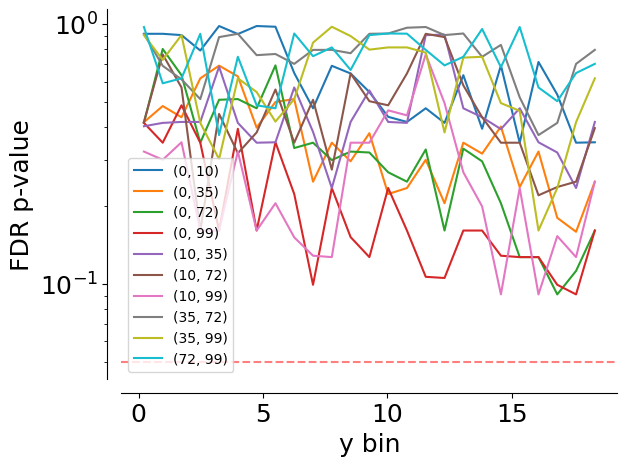

In [ ]:
sns.lineplot(data = p_value_df, x="bin", y="p_value_corr", hue=zip(p_value_df.comp1, p_value_df.comp2))
plt.ylabel("FDR p-value")
plt.xlabel("y bin")
plt.yscale("log")
plt.axhline(0.05, linestyle="dashed", color="red", alpha=0.5)

sns.despine(offset=10)
plt.savefig(save_fig_path + "Supp_contrast_pos_pvalue.svg", transparent=True)

In [92]:
p_value_df.pivot(index = "bin", columns=["comp1", "comp2"], values=["p_value_corr"])

p_value_corr                                                    \
comp1             0                                       10             
comp2             10        35        72        99        35        72   
bin                                                                      
0.2145      0.917696  0.419178  0.416565  0.416565  0.404404  0.420109   
0.9695      0.917696  0.483725  0.802045  0.349472  0.416565  0.764359   
1.7245      0.907264  0.437934  0.635808  0.486746  0.420109  0.570276   
2.4795      0.791274  0.618244  0.349472  0.349472  0.420109  0.160415   
3.2345      0.983142  0.692084  0.511305  0.160415  0.685116  0.451067   
3.9895      0.915776  0.629107  0.514542  0.395386  0.416565  0.318431   
4.7445      0.983142  0.399389  0.474207  0.160415  0.349472  0.382723   
5.5000      0.976991  0.501473  0.693569  0.350772  0.350772  0.560047   
6.2555      0.647910  0.514439  0.333347  0.221676  0.570276  0.349472   
7.0105      0.474207  0.247402  0.349472  0.099169  0.384640  0.511305   
7.7655      0.690990  0.349472  0.299595  0.233881  0.233881  0.275195   
8.5205      0.645611  0.296503  0.323070  0.151363  0.420111  0.645611   
9.2755      0.547669  0.380183  0.320397  0.126750  0.555459  0.504908   
10.0305     0.439600  0.221676  0.268865  0.233881  0.420109  0.486820   
10.7855     0.420111  0.233881  0.247402  0.160415  0.416565  0.645611   
11.5405     0.474207  0.300375  0.329128  0.106434  0.907264  0.917696   
12.2955     0.416565  0.204362  0.160415  0.105324  0.910767  0.891276   
13.0510     0.635808  0.349472  0.331583  0.160415  0.474207  0.581033   
13.8065     0.395386  0.317187  0.296236  0.160415  0.437934  0.437934   
14.5615     0.692942  0.403337  0.204362  0.128331  0.394204  0.349472   
15.3165     0.349472  0.235955  0.126750  0.126750  0.474207  0.349472   
16.0715     0.715008  0.323070  0.126750  0.126750  0.350772  0.219239   
16.8265     0.535408  0.179538  0.091081  0.099169  0.320397  0.235955   
17.5815     0.349472  0.158629  0.112135  0.091081  0.233881  0.247402   
18.3365     0.350772  0.247402  0.160415  0.160415  0.420109  0.397676   

                                                 
comp1                    35                  72  
comp2          99        72        99        99  
bin                                              
0.2145   0.323070  0.915776  0.907264  0.974521  
0.9695   0.300375  0.690990  0.728364  0.591719  
1.7245   0.350772  0.612625  0.907264  0.618354  
2.4795   0.160415  0.514439  0.416565  0.917696  
3.2345   0.160415  0.891276  0.302135  0.373887  
3.9895   0.323070  0.917696  0.618354  0.748439  
4.7445   0.160415  0.759430  0.547669  0.486746  
5.5000   0.204362  0.767311  0.421422  0.474207  
6.2555   0.150968  0.702940  0.514439  0.920252  
7.0105   0.128331  0.795770  0.848518  0.752539  
7.7655   0.126750  0.795770  0.976991  0.813409  
8.5205   0.349472  0.772676  0.899438  0.666054  
9.2755   0.349472  0.917696  0.797478  0.907264  
10.0305  0.465553  0.920252  0.813409  0.920252  
10.7855  0.445285  0.968612  0.813409  0.918743  
11.5405  0.764701  0.974521  0.776563  0.795770  
12.2955  0.496433  0.907264  0.382723  0.693569  
13.0510  0.268865  0.920252  0.743129  0.748439  
13.8065  0.198633  0.748439  0.748439  0.957600  
14.5615  0.091081  0.831806  0.496433  0.682598  
15.3165  0.233881  0.522613  0.463347  0.974521  
16.0715  0.091081  0.373887  0.160415  0.570276  
16.8265  0.152640  0.416565  0.233881  0.504908  
17.5815  0.126750  0.702940  0.419178  0.647910  
18.3365  0.247402  0.795770  0.618354  0.702940

### Velocity analysis

In [93]:
velocity_df = []
for m in sessions_list:
    #print(m)
    velocity_df.append(pd.DataFrame((MeanVelocities() & f'dataset="{m}"').fetch(as_dict=True)[0]))
velocity_df = pd.concat(velocity_df)

mean_mouse = velocity_df.groupby(["dataset", "aperture", "trial_length"],as_index=False).mean()

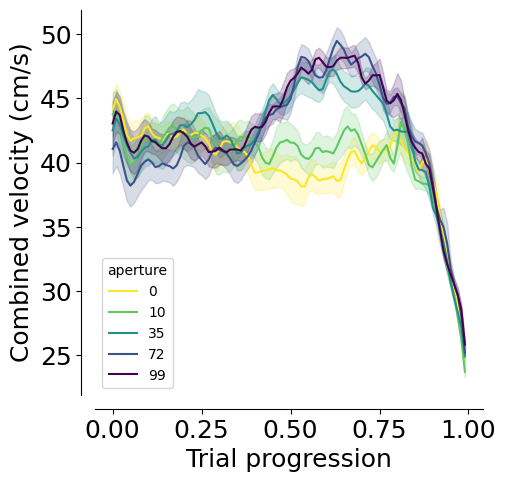

In [ ]:
aperture_to_occlusion = {
    12.0: 99,
    8.48: 72,
    6.0: 35,
    4.2: 10,
    3.0: 0
}

# Map the values
mean_mouse['aperture'] = mean_mouse['aperture'].map(aperture_to_occlusion)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
sns.lineplot(
    data=mean_mouse,
    x="trial_length",
    y="velocity",
    palette=plotting.colors_multi_aperture,
    hue="aperture",
    errorbar="se",
    ax=ax,
)

sns.despine(offset=10)
ax.set_xlabel("Trial progression")
ax.set_ylabel("Combined velocity (cm/s)")
plt.savefig(save_fig_path + "Supp_contrast_velocity.svg", transparent=True)

In [95]:
print(
    AnovaRM(
        data=mean_mouse,
        depvar="velocity",
        subject="dataset",
        within=["aperture", "trial_length"],
    ).fit()
)

                         Anova
                      F Value  Num DF    Den DF  Pr > F
-------------------------------------------------------
aperture               8.0183   4.0000   36.0000 0.0001
trial_length          36.1984  99.0000  891.0000 0.0000
aperture:trial_length  4.9314 396.0000 3564.0000 0.0000



In [96]:
p_value_df = get_multi_p_values_binned(mean_mouse, x_var="trial_length", y_var="velocity")

In [97]:
p_value_df

,bin,comp1,comp2,p_value,p_value_corr
0,0.00,0,10,0.754650,0.902255
0,0.00,0,35,0.330019,0.603528
0,0.00,0,72,0.079434,0.248753
0,0.00,0,99,0.453723,0.713401
0,0.00,10,35,0.336848,0.611340
...,...,...,...,...,...
0,0.99,10,72,0.016952,0.086052
0,0.99,10,99,0.002576,0.023204
0,0.99,35,72,0.587979,0.811488
0,0.99,35,99,0.061206,0.214005


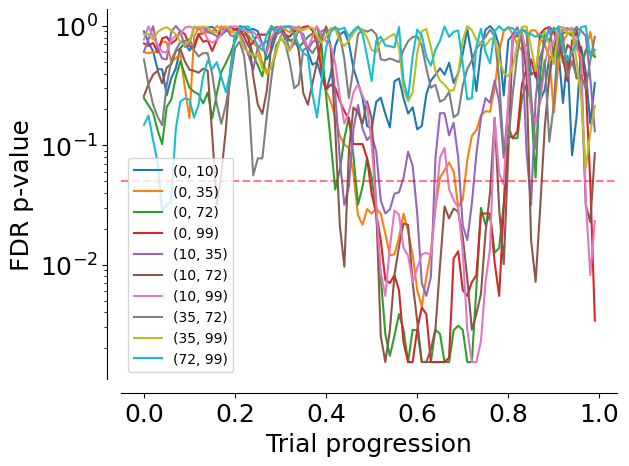

In [ ]:
sns.lineplot(data = p_value_df, x="bin", y="p_value_corr", hue=zip(p_value_df.comp1, p_value_df.comp2))
plt.ylabel("FDR p-value")
plt.xlabel("Trial progression")
plt.axhline(0.05, linestyle="dashed", color="red", alpha=0.5)
plt.yscale("log")

sns.despine(offset=10)
plt.savefig(save_fig_path + "Supp_contrast_velocity_pvalue.svg", transparent=True)

### Prediction model

In [99]:
model_key = {"label_set_id": 8, "params_id": 1}

In [100]:
task_type_key = {"set_name": "contrast_black_target",
                 "stage_name": "multi_occlusion",}

In [122]:
# Coefficients for dual occluder task
coef = (PredictionModel() & task_type_key & model_key).fetch1("coefficients")

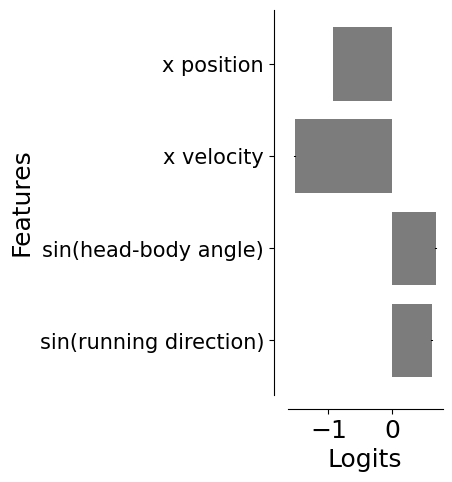

In [ ]:
# Logits of the regression
model_labels, clean_labels = (LabelSet.Member * Label & model_key).fetch("label_key", "clean_name")

fig, ax = plt.subplots(1, 1, figsize=(2, 5))
ax.barh(
    model_labels,
    np.mean(coef[:, 1:], axis=0),
    yerr=stats.sem(coef[:, 1:], axis=0),
    color="#7C7C7C",
)
sns.despine(offset=10, ax=ax)

ax.set_yticks(np.arange(len(model_labels)))
ax.set_yticklabels(clean_labels, rotation=0, ha="right", fontsize=15)
ax.set_xlabel("Logits")
ax.set_ylabel("Features")

plt.savefig(
    save_fig_path + "Supp_contrast_model_logits.svg", transparent=False
)

In [ ]:
prediction_df = pd.DataFrame((PredictionModel().SessionPrediction() & model_key & task_type_key).fetch(
    "dataset", "trial", "proba_left", "accuracy", "trial_length", as_dict=True)).explode(["trial", "proba_left", "accuracy", "trial_length"])

In [ ]:
df_model = prediction_df.merge(
    interpolated_df[["dataset", "trial_length", "trial", "aperture", "trial_left_choice", "x", "y"]], on=["dataset", "trial", "trial_length"]
)

df_model["accuracy"] = df_model["accuracy"].astype(float)
df_model["proba_left"] = df_model["proba_left"].astype(float)

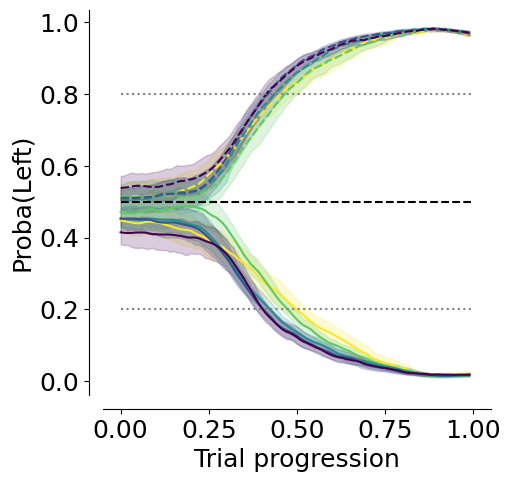

In [ ]:
df_model_mean = df_model.groupby(["dataset", "aperture", "trial_left_choice", "trial_length"], as_index=False).mean()
fig, ax = plt.subplots(1, 1, figsize=(5, 5))

dash_styles = {
    df_model_mean.aperture.unique()[0]: "",         # Solid
    df_model_mean.aperture.unique()[1]: (5, 5)      # Dashed
}
    
sns.lineplot(
    data=df_model_mean,
    x="trial_length",
    y="proba_left",
    hue="aperture",
    style="trial_left_choice",
    palette=plotting.colors_multi_aperture,
    sort=False,
    alpha=1,
    ax=ax,
)

ax.hlines(0.5, xmin=0, xmax=1, colors="black", linestyles="dashed")
ax.hlines(0.8, xmin=0, xmax=1, colors="gray", linestyles="dotted")
ax.hlines(0.2, xmin=0, xmax=1, colors="gray", linestyles="dotted")
ax.set_ylabel("Proba(Left)")
ax.set_xlabel("Trial progression")
sns.despine(offset=10)
plt.legend([], [], frameon=False)
plt.savefig(
    save_fig_path + "Supp_contrast_dynamic_decision_variable_mean.svg", transparent=True
)
plt.savefig(
    save_fig_path + "Supp_contrast_dynamic_decision_variable_mean.png", transparent=True, dpi=300
)

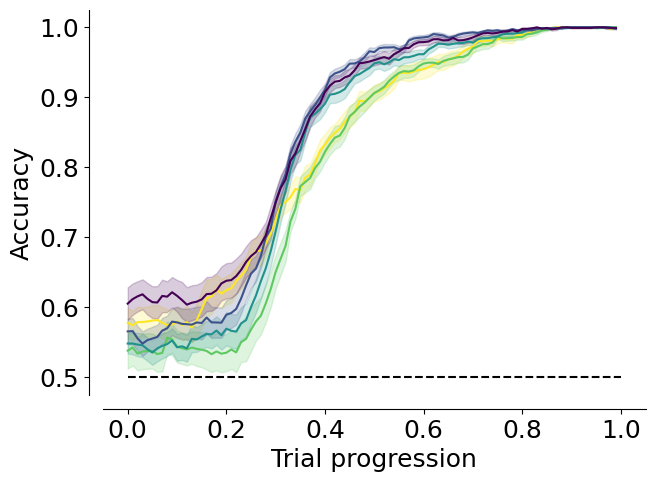

In [ ]:
# Accuracy
df_model_mean =  df_model.groupby(["dataset", "aperture", "trial_length"], as_index=False).mean()

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
sns.lineplot(
    ax=ax,
    data=df_model_mean,
    y="accuracy",
    x="trial_length",
    hue="aperture",
    palette=plotting.colors_multi_aperture,
    errorbar="se",
)
sns.despine(offset=10)
ax.set_xlabel("Trial progression")
ax.set_ylabel("Accuracy")
ax.hlines(0.5, 0, 1, color="black", linestyle="--")
plt.legend([], [], frameon=False)

plt.savefig(
    save_fig_path + "Supp_contrast_model_accuracy.svg", transparent=False
)

In [ ]:
df_model["trial_length_bin"] = pd.cut(
    df_model["trial_length"], bins=50
)

df_anova = df_model.groupby(
    ["dataset", "aperture", "trial_length_bin"], as_index=False
).mean(numeric_only=True)

print(
    AnovaRM(
        data=df_anova,
        depvar="accuracy",
        subject="dataset",
        within=["aperture", "trial_length_bin"],
    ).fit()
)

                           Anova
                          F Value   Num DF    Den DF  Pr > F
------------------------------------------------------------
aperture                   11.4916   4.0000   96.0000 0.0000
trial_length_bin          474.8240  49.0000 1176.0000 0.0000
aperture:trial_length_bin   4.3735 196.0000 4704.0000 0.0000



## Get the decision points

In [ ]:
decision_points = pd.DataFrame((DecisionPoints() & task_type_key & model_key & "threshold_uncertainty = 0.2").fetch(as_dict=True))
decision_points = decision_points.explode(["trial", "aperture", "trial_length", "trial_left_choice", "proba_left", "x", "y", "trial_rewarded"])
decision_points["mouse_name"] = decision_points.dataset.str.split("_").str[0]
decision_points["y"] = decision_points["y"].astype(float)

### Get distance to screen at decision point

3.0-4.2: TtestResult(statistic=0.49739267320565256, pvalue=0.6234385950886467, df=24)
 mean difference:  -0.4588393517271001
3.0-6.0: TtestResult(statistic=1.693880063404927, pvalue=0.10322884643216759, df=24)
 mean difference:  -1.4844673241082784
3.0-8.48: TtestResult(statistic=3.1792023984838473, pvalue=0.004038831906936139, df=24)
 mean difference:  -2.471162040680559
mean: 13.497117945523021 +/- 0.5902315830199871
4.2-6.0: TtestResult(statistic=1.4004289297852808, pvalue=0.1741812780717876, df=24)
 mean difference:  -1.0256279723811783
4.2-8.48: TtestResult(statistic=2.7248202118290044, pvalue=0.011813735411151478, df=24)
 mean difference:  -2.012322688953459
mean: 13.038278593795921 +/- 0.5588690162720868
6.0-8.48: TtestResult(statistic=1.5436863271887404, pvalue=0.135748808870696, df=24)
 mean difference:  -0.9866947165722806
mean: 12.012650621414743 +/- 0.49183009302876524
mean: 11.025955904842462 +/- 0.4311999013527618
12.0-3.0: TtestResult(statistic=-3.942764100540485, pvalue

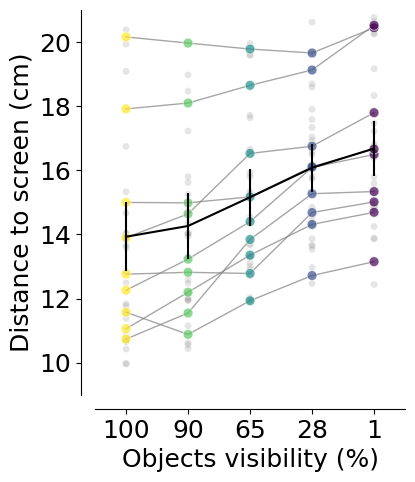

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(4, 5))
_ = plotting.pairplot_average_decision_point(
    decision_points,
    label_parameter="y",
    ax=ax,
    cmap=plotting.colors_multi_aperture,
    per_mouse=True,
)
ax.set_xlabel("Objects visibility (%)")
ax.set_ylim(9, 21)
ax.set_xlim(-0.5, 4.5)
ax.set_xticks([0, 1, 2, 3, 4], ["100", "90", "65", "28", "1"])
plt.legend([], [], frameon=False)
sns.despine(offset=10)

plt.savefig(
    save_fig_path + "Supp_contrast_decision_points_distance.svg",
    transparent=True,
)